"""
PAKISTANI POLITICIAN IMAGE CLASSIFIER - COMPLETE TRAINING PIPELINE
===================================================================
100% STANDALONE - INCLUDES EVERYTHING:
   ✓ Data Collection (Web Scraping + Face Detection)
   ✓ Data Splitting (Train/Val/Test)
   ✓ Data Augmentation
   ✓ Model Training (5 CNN Models)
   ✓ Evaluation & Results

INSTRUCTIONS:
   1. Upload this file to Kaggle
   2. Enable GPU (Settings → Accelerator → GPU)
   3. Run all cells (or run as script: python kaggle_training_complete.py)
   4. Download results from /kaggle/working/

ESTIMATED TIME: 4-6 hours (with GPU)

OUTPUT:
   - /kaggle/working/models/*.pth (trained models)
   - /kaggle/working/plots/*.png (training curves, confusion matrices)
   - /kaggle/working/results/*.csv (evaluation results)

Author: M.Hanzala
Version: 2.0 - COMPLETE STANDALONE
"""

In [1]:
!pip install --no-deps facenet-pytorch imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.5 MB/s eta 0:00:0000:0100:01


In [ ]:
!pip install -q ImageEngine gallery-thief newspaper3k

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from copy import deepcopy

# Hide common ugly but usually non-critical warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


SECTION 1: SETUP & IMPORTS
============================================================================

In [3]:
print("="*70)
print("PAKISTANI POLITICIAN IMAGE CLASSIFIER")
print("="*70)
print("Installing required packages...")

PAKISTANI POLITICIAN IMAGE CLASSIFIER
Installing required packages...


In [4]:
# Install packages if needed (for Kaggle)
import subprocess
import sys

In [ ]:
# Install required packages
!pip install -q lxml_html_clean
packages = [
    'icrawler',
    'albumentations',
    'timm',
    'ImageEngine',
    'gallery-thief',
    'newspaper3k',
]

In [6]:
# Install required packages
packages = [
    'icrawler',
    'albumentations',
    'timm',
]

In [7]:
for pkg in packages:
    install_package(pkg)

Installing icrawler...


In [8]:
print("✓ All packages ready!")

✓ All packages ready!


In [ ]:
import os
import sys
import time
# Added for alignment math and perceptual hash dedup.
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
import cv2
import shutil
from collections import defaultdict, Counter
# Added for perceptual hash deduplication.
import imagehash
# Added for image crawling
from icrawler.builtin import BingImageCrawler, BaiduImageCrawler

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm
# Added face alignment model and face-pretrained backbone.
from facenet_pytorch import MTCNN, InceptionResnetV1

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)
# Added for class-weighted loss.
from sklearn.utils.class_weight import compute_class_weight

In [13]:
# ============================================================================
# AUTOMATIC RESULTS CLEANUP SYSTEM
# ============================================================================

def cleanup_previous_results():
    """Clean up previous training results before new runs"""
    print("Cleaning previous results...")
    
    directories_to_clean = [
        'plots/', 'results/', 'models/saved/', 
        'notebooks/project_outputs/'
    ]
    
    cleaned_count = 0
    for dir_path in directories_to_clean:
        try:
            if os.path.exists(dir_path):
                shutil.rmtree(dir_path)
                cleaned_count += 1
                print(f"   ✓ Cleaned: {dir_path}")
            os.makedirs(dir_path, exist_ok=True)
        except Exception as e:
            print(f"   WARNING: Failed to clean {dir_path}: {e}")
    
    print(f"✓ Cleanup complete! Cleaned {cleaned_count} directories")
    return cleaned_count

# Run cleanup at start
cleanup_previous_results()

Cleaning previous results...
✓ Cleanup complete! Cleaned 0 directories


0

In [14]:
print("✓ Focal Loss implementation ready")

✓ Focal Loss implementation ready


In [15]:
print("✓ Enhanced augmentation pipeline (14 techniques) ready")
print("   • Geometric: ShiftScaleRotate, Perspective")
print("   • Color: RandomGamma")
print("   • Noise/Blur: MotionBlur, GaussNoise")
print("   • Occlusion: CoarseDropout")

✓ Enhanced augmentation pipeline (14 techniques) ready
   • Geometric: ShiftScaleRotate, Perspective
   • Color: RandomGamma
   • Noise/Blur: MotionBlur, GaussNoise
   • Occlusion: CoarseDropout


In [16]:
# ============================================================================
# ENSEMBLE PREDICTION SYSTEM
# ============================================================================

def ensemble_predict(models, image_tensor):
    """Ensemble prediction from multiple models"""
    predictions = []
    
    for model in models:
        model.eval()
        with torch.no_grad():
            pred = F.softmax(model(image_tensor), dim=1)
            predictions.append(pred)
    
    # Average predictions
    ensemble_pred = torch.mean(torch.stack(predictions), dim=0)
    return ensemble_pred

def evaluate_ensemble(models, test_loader, class_names):
    """Evaluate ensemble on test set"""
    correct = 0
    total = 0
    
    for images, labels in tqdm(test_loader, desc="Ensemble Evaluation"):
        images, labels = images.to(device), labels.to(device)
        
        ensemble_pred = ensemble_predict(models, images)
        _, predicted = torch.max(ensemble_pred, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

print("✅ Ensemble prediction system ready")

✅ Ensemble prediction system ready


In [17]:
print("ENHANCED PIPELINE FOR 90% ACCURACY LOADED!")
print("="*60)
print("IMPROVEMENTS APPLIED:")
print("   ✓ Face Detection: 5% → 2% threshold (retain more images)")
print("   ✓ Augmentation: 2x → 5x multiplier (better generalization)")
print("   ✓ Training: 20 → 30 epochs, 5 → 7 patience")
print("   ✓ Models: Added EfficientNet-B4")
print("   ✓ Loss: Added Focal Loss for class imbalance")
print("   ✓ Evaluation: Added ensemble predictions")
print("   ✓ Advanced: 14 augmentation techniques")
print("   ✓ Cleanup: Automatic results cleanup")
print("")
print("TARGET: 90% accuracy (from current 76%)")
print("EXPECTED IMPROVEMENT: +14% accuracy gain")
print("ESTIMATED TIME: 6-8 hours with GPU")
print("="*60)

ENHANCED PIPELINE FOR 90% ACCURACY LOADED!
IMPROVEMENTS APPLIED:
   ✓ Face Detection: 5% → 2% threshold (retain more images)
   ✓ Augmentation: 2x → 5x multiplier (better generalization)
   ✓ Training: 20 → 30 epochs, 5 → 7 patience
   ✓ Models: Added EfficientNet-B4
   ✓ Loss: Added Focal Loss for class imbalance
   ✓ Evaluation: Added ensemble predictions
   ✓ Advanced: 14 augmentation techniques
   ✓ Cleanup: Automatic results cleanup

TARGET: 90% accuracy (from current 76%)
EXPECTED IMPROVEMENT: +14% accuracy gain
ESTIMATED TIME: 6-8 hours with GPU


In [18]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [19]:
set_seed(42)

In [20]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Using device: cuda
   GPU: Tesla T4
   Memory: 15.64 GB


============================================================================
SECTION 2: CONFIGURATION
============================================================================

In [ ]:
class Config:
    """Training configuration"""
    # Paths - use local dataset after collection
    RAW_DIR = "data/raw"
    ALIGNED_DIR = "data/aligned"
    DATA_DIR = "dataset"  # Local dataset after splitting
    OUTPUT_DIR = "/kaggle/working" if os.path.exists("/kaggle") else "output"

    # Dataset
    NUM_CLASSES = 16
    CLASS_NAMES = sorted([
        "ahmed_sharif_chaudhry", "ahsan_iqbal", "altaf_hussain", "asfandyar_wali",
        "asif_ali_zardari", "barrister_gohar", "bilawal_bhutto", "chaudhry_shujaat",
        "fazlur_rehman", "imran_khan", "khawaja_asif", "maryam_nawaz",
        "nawaz_sharif", "pervez_musharraf", "shahbaz_sharif", "shehryar_afridi"
    ])

    # Training hyperparameters
    EPOCHS = 50
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 0.0001
    EARLY_STOPPING_PATIENCE = 15

    # Models to train (face-pretrained backbone included for accuracy-first)
    MODELS_TO_TRAIN = ["inception_resnet_v1", "inception_resnet_v1_casia"]
    MODEL_BACKBONE = "inception_resnet_v1"

    # Image settings
    # Accuracy-first: keep higher resolution for identity detail.
    IMAGE_SIZE = 336
    IMG_SIZE = IMAGE_SIZE  # Backward compatibility for older references

    # Augmentation (offline only for small classes)
    USE_OFFLINE_AUGMENTATION = True
    NUM_AUGMENTATIONS = 3
    MIN_IMAGES_FOR_OFFLINE_AUG = 120

    # Face alignment + dedup
    # Accuracy-first: align faces and remove duplicates.
    USE_FACE_ALIGNMENT = True
    ALIGN_MARGIN = 0.2
    # Accuracy-first: remove near-duplicates for clean data.
    REMOVE_DUPLICATES = True
    DEDUP_PHASH_DISTANCE = 5
    MIN_IMAGES_FOR_SPLIT = 5

    # Legacy Haar parameters (used only when USE_FACE_ALIGNMENT=False)
    MIN_FACE_RATIO = 0.02
    FACE_SCALE_FACTOR = 1.03
    FACE_MIN_NEIGHBORS = 2
    FACE_MIN_SIZE = (15, 15)

    # Loss and class balancing
    USE_FOCAL_LOSS = True
    FOCAL_ALPHA = 1
    FOCAL_GAMMA = 2
    # Accuracy-first: keep class weights enabled.
    USE_CLASS_WEIGHTS = True

    # MixUp
    USE_MIXUP = False  # Disabled when using ArcFace (not compatible)
    # Accuracy-first: keep MixUp alpha and probability.
    MIXUP_ALPHA = 0.2
    MIXUP_PROB = 0.5

    # Evaluation
    # Accuracy-first: 5-view TTA (4 corners + center).
    USE_TTA = True
    TTA_NUM_AUGMENTATIONS = 5
    SHOW_MISCLASSIFIED = True
    USE_ENSEMBLE = True

    # ArcFace / AdaCos
    USE_ARCFACE = True
    USE_ADACOS = True
    ARCFACE_MARGIN = 0.15
    ARCFACE_WARMUP_EPOCHS = 5
    ARCFACE_FINAL_MARGIN = 0.25
    ARCFACE_SCALE = 64.0
    ARCFACE_WEIGHT_DECAY = 1e-4
    ARCFACE_USE_CLASS_WEIGHTS = False
    HEAD_LR = 1e-4
    ARCFACE_WEIGHT_LR = 1e-4
    BACKBONE_UNFREEZE_LR = 5e-6

    # Additional crawler control
    USE_BAIDU = True

    # DataLoader workers - keep 0 for notebook/Windows safety, configurable
    NUM_WORKERS = 0

In [ ]:
# ArcFace implementation (additive angular margin softmax)
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ArcMarginProduct(nn.Module):
    """Implements large margin arc distance: produces cos(theta) logits scaled by `s`.
    Reference: ArcFace (Deng et al.) implementation pattern.
    """
    def __init__(self, in_features, out_features, s=64.0, m=0.5, easy_margin=False):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.easy_margin = easy_margin
        self._set_margin(m)

    def _set_margin(self, margin):
        self.m = float(margin)
        self.cos_m = math.cos(self.m)
        self.sin_m = math.sin(self.m)
        self.th = math.cos(math.pi - self.m)
        self.mm = math.sin(math.pi - self.m) * self.m

    @property
    def margin(self):
        return self.m

    @margin.setter
    def margin(self, value):
        self._set_margin(value)

    def forward(self, input, label=None):
        # input is embeddings: (batch, in_features)
        # weight: (out_features, in_features)
        # compute normalized cosine
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))  # (batch, out_features)
        if label is None:
            # inference: return scaled cosine
            return cosine * self.s

        sine = torch.sqrt(torch.clamp(1.0 - cosine ** 2, 0.0, 1.0))
        phi = cosine * self.cos_m - sine * self.sin_m  # cos(theta + m)

        if self.easy_margin:
            phi = torch.where(cosine > 0, phi, cosine)
        else:
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)

        # convert label to one-hot
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, label.view(-1, 1), 1.0)

        # where one_hot==1, use phi; else use cosine
        logits = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        logits = logits * self.s
        return logits

class ArcFaceLoss(nn.Module):
    """Wrapper loss that computes ArcFace logits then cross-entropy.
    Accepts embeddings and labels and optional class weights.
    """
    def __init__(self, in_features, num_classes, s=64.0, m=0.5, class_weights=None, easy_margin=False):
        super().__init__()
        self.margin_product = ArcMarginProduct(in_features, num_classes, s=s, m=m, easy_margin=easy_margin)
        if class_weights is not None:
            if isinstance(class_weights, (list, tuple)):
                class_weights = torch.tensor(class_weights, dtype=torch.float)
            self.register_buffer('class_weights', class_weights)
            self.criterion = nn.CrossEntropyLoss(weight=self.class_weights)
        else:
            self.class_weights = None
            self.criterion = nn.CrossEntropyLoss()

    def forward(self, embeddings, labels):
        logits = self.margin_product(embeddings, labels)
        loss = self.criterion(logits, labels)
        return loss, logits

# Ensure MixUp is disabled when using ArcFace (not compatible)
if Config.USE_ARCFACE:
    Config.USE_MIXUP = False
    print("Config: ArcFace enabled -> MixUp disabled")


Config: ArcFace enabled -> MixUp disabled


In [ ]:
class AdaCos(nn.Module):
    def __init__(self, num_classes, embedding_size=512):
        super().__init__()
        self.W = nn.Parameter(torch.randn(num_classes, embedding_size))
        nn.init.xavier_normal_(self.W)
        # Fixed scale based on class count
        self.s = math.sqrt(2) * math.log(num_classes - 1)

    def logits(self, embeddings):
        embeddings = F.normalize(embeddings, dim=1)
        W_norm = F.normalize(self.W, dim=1)
        return self.s * embeddings @ W_norm.t()

    def forward(self, embeddings, labels):
        # Normalize embeddings and weights
        embeddings = F.normalize(embeddings, dim=1)
        W_norm = F.normalize(self.W, dim=1)
        # Cosine logits with fixed scale
        logits = self.s * embeddings @ W_norm.t()
        loss = F.cross_entropy(logits, labels)
        return loss

In [ ]:
# Model wrapper for InceptionResnetV1 + head and ArcFace training helper
from facenet_pytorch import InceptionResnetV1
import torchvision.models as tv_models

class FaceEmbeddingModel(nn.Module):
    """Wraps InceptionResnetV1 to expose embeddings and a simple head."""
    def __init__(self, num_classes, pretrained='vggface2', dropout=0.5):
        super().__init__()
        self.backbone = InceptionResnetV1(pretrained=pretrained, classify=False, device=None)
        self.embedding_size = 512
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.embedding_size, num_classes)
        )

    def forward(self, x, return_embeddings=False):
        embeddings = self.backbone(x)
        embeddings = F.normalize(embeddings, p=2, dim=1)

        # In ArcFace mode, the model outputs embeddings only.
        if Config.USE_ARCFACE:
            return embeddings

        if return_embeddings:
            return embeddings

        logits = self.head(embeddings)
        return logits, embeddings


class EfficientNetEmbeddingModel(nn.Module):
    """Wraps EfficientNet-B3 and projects features to 512-d embeddings for ArcFace."""
    def __init__(self, num_classes, pretrained=True, embedding_size=512, dropout=0.5):
        super().__init__()
        # Use torchvision EfficientNet-B3
        try:
            backbone = tv_models.efficientnet_b3(weights=tv_models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        except Exception:
            # Fallback for older torchvision versions
            backbone = tv_models.efficientnet_b3(pretrained=pretrained)
        # remove classifier
        self.backbone = backbone
        if hasattr(self.backbone, 'classifier'):
            self.backbone.classifier = nn.Identity()
        self.embedding_size = embedding_size
        # infer feature dim by a forward hook won't run here; assume EfficientNet-B3 out_features=1536
        feat_dim = 1536
        self.project = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, self.embedding_size),
            nn.BatchNorm1d(self.embedding_size),
            nn.ReLU()
        )
        self.head = nn.Linear(self.embedding_size, num_classes)

    def forward(self, x, return_embeddings=False):
        # pass through backbone features -> pool -> flatten
        features = self.backbone(x)  # after classifier removed, should be (B, feat_dim)
        embeddings = self.project(features)
        embeddings = F.normalize(embeddings, p=2, dim=1)

        # In ArcFace mode, the model outputs embeddings only.
        if Config.USE_ARCFACE:
            return embeddings

        if return_embeddings:
            return embeddings

        logits = self.head(embeddings)
        return logits, embeddings


def train_arcface(model, train_loader, val_loader, config: Config, device=None):
    """Train a FaceEmbeddingModel using ArcFaceLoss. Returns best model and history."""
    device = device or (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
    model = model.to(device)

    # Track model family for architecture-specific unfreeze behavior.
    if isinstance(model, EfficientNetEmbeddingModel):
        model_name = "efficientnet_b3"
    else:
        model_name = "inception_resnet_v1"

    # Freeze backbone initially
    for param in model.backbone.parameters():
        param.requires_grad = False
    for param in model.head.parameters():
        param.requires_grad = True

    # ArcFace loss
    class_weights = None
    if config.USE_CLASS_WEIGHTS:
        try:
            # try to get class_weights from dataset
            if hasattr(train_loader.dataset, 'class_weights'):
                class_weights = train_loader.dataset.class_weights
        except Exception:
            class_weights = None

    arcface_loss = ArcFaceLoss(
        in_features=model.embedding_size,
        num_classes=config.NUM_CLASSES,
        s=config.ARCFACE_SCALE,
        m=config.ARCFACE_MARGIN,
        class_weights=class_weights
    ).to(device)
    criterion = arcface_loss

    # Keep the early margin easier, then raise it after warmup so ArcFace stabilizes before the harder separation.
    original_margin = criterion.margin_product.margin

    # Optimizer: include trainable model params + ArcFace params.
    trainable_model_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(
        [
            {'params': trainable_model_params, 'lr': config.HEAD_LR},
            {'params': criterion.parameters(), 'lr': config.ARCFACE_WEIGHT_LR, 'weight_decay': config.ARCFACE_WEIGHT_DECAY}
        ],
        weight_decay=config.WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.EPOCHS)

    best_val_acc = -1.0
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, config.EPOCHS + 1):
        model.train()
        arcface_loss.train()
        running_loss = 0.0
        correct_margin = 0
        correct_nomargin = 0
        total = 0

        # ArcFace margin warmup: use the easier margin for the first few epochs, then switch to the final margin.
        if epoch <= config.ARCFACE_WARMUP_EPOCHS:
            criterion.margin_product.margin = config.ARCFACE_MARGIN
        else:
            criterion.margin_product.margin = config.ARCFACE_FINAL_MARGIN

        for batch in train_loader:
            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images, return_embeddings=True)
            embeddings = outputs[1] if isinstance(outputs, tuple) else outputs

            loss, logits = criterion(embeddings, labels)
            logits_nomargin = criterion.margin_product(embeddings, label=None)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            torch.nn.utils.clip_grad_norm_(criterion.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds_margin = logits.argmax(dim=1)
            preds_nomargin = logits_nomargin.argmax(dim=1)
            correct_margin += (preds_margin == labels).sum().item()
            correct_nomargin += (preds_nomargin == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / max(total, 1)
        epoch_acc_margin = correct_margin / max(total, 1)
        epoch_acc_nomargin = correct_nomargin / max(total, 1)

        # Validation
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        model.eval()
        criterion.eval()
        with torch.no_grad():
            for batch in val_loader:
                images, labels = batch
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images, return_embeddings=True)
                embeddings = outputs[1] if isinstance(outputs, tuple) else outputs

                # Validation metrics/logits should be computed without angular margin.
                logits = criterion.margin_product(embeddings, label=None)
                loss = criterion.criterion(logits, labels)

                val_loss += loss.item() * images.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / max(val_total, 1)
        val_acc = val_correct / max(val_total, 1)

        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch {epoch}/{config.EPOCHS} | Train Loss: {epoch_loss:.4f} | "
            f"Train Acc (margin): {epoch_acc_margin:.4f} | Train Acc (no-margin): {epoch_acc_nomargin:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        # Unfreeze backbone at epoch 6 (architecture-specific selective unfreeze)
        if epoch == 6:
            if model_name and "inception_resnet_v1" in model_name:
                # Unfreeze the last three major blocks rather than only the final block.
                inception_unfreeze_prefixes = (
                    'repeat_2',
                    'mixed_7a',
                    'repeat_3',
                    'block8',
                    'last_linear',
                    'last_bn'
                )
                unfrozen_count = 0
                for name, param in model.backbone.named_parameters():
                    if any(name.startswith(prefix) for prefix in inception_unfreeze_prefixes):
                        param.requires_grad = True
                        unfrozen_count += 1
                print(f"Inception selective unfreeze: unfroze {unfrozen_count} backbone params.")
            elif model_name == "efficientnet_b3":
                # Torchvision EfficientNet-B3 uses `features.*` naming; keep `stages.*` as compatibility fallback.
                efficientnet_unfreeze_prefixes = (
                    'features.6', 'features.7', 'features.8',
                    'stages.6', 'stages.7'
                )
                unfrozen_count = 0
                for name, param in model.backbone.named_parameters():
                    if any(name.startswith(prefix) for prefix in efficientnet_unfreeze_prefixes):
                        param.requires_grad = True
                        unfrozen_count += 1

                # Safety fallback in case naming differs: unfreeze the tail parameters.
                if unfrozen_count == 0:
                    named_params = list(model.backbone.named_parameters())
                    tail_count = max(1, int(len(named_params) * 0.2))
                    for name, param in named_params[-tail_count:]:
                        param.requires_grad = True
                        unfrozen_count += 1
                print(f"EfficientNet selective unfreeze: unfroze {unfrozen_count} backbone params.")

            # Rebuild optimizer with explicit LR groups.
            head_params = [p for p in model.head.parameters() if p.requires_grad]
            backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
            optimizer = torch.optim.AdamW(
                [
                    {'params': head_params, 'lr': config.HEAD_LR},
                    {'params': criterion.parameters(), 'lr': config.ARCFACE_WEIGHT_LR, 'weight_decay': config.ARCFACE_WEIGHT_DECAY},
                    {'params': backbone_params, 'lr': config.BACKBONE_UNFREEZE_LR}
                ],
                weight_decay=config.WEIGHT_DECAY
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, config.EPOCHS - epoch))
            print("Selective unfreeze: unfreezing final backbone block and updating optimizer.")

        # Full-backbone unfreeze at epoch 12.
        if False and epoch == 12:
            for param in model.backbone.parameters():
                param.requires_grad = True
            head_params = [p for p in model.head.parameters() if p.requires_grad]
            backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
            optimizer = torch.optim.AdamW(
                [
                    {'params': head_params, 'lr': config.HEAD_LR},
                    {'params': criterion.parameters(), 'lr': config.ARCFACE_WEIGHT_LR, 'weight_decay': config.ARCFACE_WEIGHT_DECAY},
                    {'params': backbone_params, 'lr': config.BACKBONE_UNFREEZE_LR}
                ],
                weight_decay=config.WEIGHT_DECAY
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, config.EPOCHS - epoch))
            print("Epoch 12 full-backbone unfreeze activated.")

        # Second unfreeze for Inception variants at epoch 15.
        if False and epoch == 15 and (model_name and "inception_resnet_v1" in model_name):
            for param in model.backbone.parameters():
                param.requires_grad = True
            head_params = [p for p in model.head.parameters() if p.requires_grad]
            backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
            optimizer = torch.optim.AdamW(
                [
                    {'params': head_params, 'lr': config.HEAD_LR},
                    {'params': criterion.parameters(), 'lr': config.ARCFACE_WEIGHT_LR, 'weight_decay': config.ARCFACE_WEIGHT_DECAY},
                    {'params': backbone_params, 'lr': config.BACKBONE_UNFREEZE_LR}
                ],
                weight_decay=config.WEIGHT_DECAY
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, config.EPOCHS - epoch))
            print("Epoch 15 Inception full-backbone unfreeze activated.")

        scheduler.step()

        # Save best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {
                'model': deepcopy(model.state_dict()),
                'arcface': deepcopy(criterion.state_dict())
            }

    # Restore best state if available.
    if best_state is not None:
        model.load_state_dict(best_state['model'])
        criterion.load_state_dict(best_state['arcface'])

    # Keep ArcFace classifier parameters for evaluation logits.
    model.arcface_eval = {
        'weight': criterion.margin_product.weight.detach().cpu().clone(),
        's': float(criterion.margin_product.s)
    }

    criterion.margin_product.margin = original_margin

    return model, history

In [24]:
# Unit test: embedding models + ArcFace loss (no training)
# NOTE: This cell requires `config = Config()` to have been executed earlier.
# For safety when running out-of-order, create a minimal `config` instance if missing.
if 'config' not in globals():
    config = Config()
    config.SOURCE_DIR = config.ALIGNED_DIR if config.USE_FACE_ALIGNMENT else config.RAW_DIR

print("Unit test: embeddings + ArcFace loss")

m1 = FaceEmbeddingModel(num_classes=config.NUM_CLASSES)
m2 = EfficientNetEmbeddingModel(num_classes=config.NUM_CLASSES)

m1.eval(); m2.eval()

# Use CPU tensors for a light, environment-independent check
x = torch.randn(4, 3, config.IMAGE_SIZE, config.IMAGE_SIZE)

with torch.no_grad():
    out1 = m1(x)
    out2 = m2(x)

    # Models return (logits, embeddings)
    if isinstance(out1, tuple):
        logits1, emb1 = out1
    else:
        # some wrappers may return embeddings only when asked; attempt call with return_embeddings
        try:
            emb1 = m1(x, return_embeddings=True)
            logits1 = None
        except Exception:
            raise RuntimeError("FaceEmbeddingModel did not return expected outputs for unit test")

    if isinstance(out2, tuple):
        logits2, emb2 = out2
    else:
        try:
            emb2 = m2(x, return_embeddings=True)
            logits2 = None
        except Exception:
            raise RuntimeError("EfficientNetEmbeddingModel did not return expected outputs for unit test")

    assert emb1.shape == (4, 512), f"FaceEmbeddingModel embeddings shape mismatch: {emb1.shape}"
    assert emb2.shape == (4, 512), f"EfficientNetEmbeddingModel embeddings shape mismatch: {emb2.shape}"

    arc = ArcFaceLoss(in_features=512, num_classes=config.NUM_CLASSES, s=config.ARCFACE_SCALE, m=config.ARCFACE_MARGIN)
    labels = torch.randint(0, config.NUM_CLASSES, (4,))
    loss, logits = arc(emb1, labels)

print("Unit test passed: embedding shapes OK and ArcFace loss computed")

Unit test: embeddings + ArcFace loss


  0%|          | 0.00/107M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 197MB/s]


Unit test passed: embedding shapes OK and ArcFace loss computed


In [ ]:
def train_adacos(model, train_loader, val_loader, config: Config, device=None):
    """Train a FaceEmbeddingModel using AdaCos. Returns best model and history."""
    device = device or (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
    model = model.to(device)

    if isinstance(model, EfficientNetEmbeddingModel):
        model_name = "efficientnet_b3"
    else:
        model_name = "inception_resnet_v1"

    for param in model.backbone.parameters():
        param.requires_grad = False
    for param in model.head.parameters():
        param.requires_grad = True

    criterion = AdaCos(num_classes=config.NUM_CLASSES, embedding_size=model.embedding_size).to(device)

    trainable_model_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(
        [
            {'params': trainable_model_params, 'lr': config.HEAD_LR},
            {'params': criterion.parameters(), 'lr': config.ARCFACE_WEIGHT_LR}
        ],
        weight_decay=config.WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.EPOCHS)

    best_val_acc = -1.0
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, config.EPOCHS + 1):
        model.train()
        criterion.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch in train_loader:
            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images, return_embeddings=True)
            embeddings = outputs[1] if isinstance(outputs, tuple) else outputs

            logits = criterion.logits(embeddings)
            loss = criterion(embeddings, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            torch.nn.utils.clip_grad_norm_(criterion.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / max(total, 1)
        epoch_acc = correct / max(total, 1)

        val_loss = 0.0
        val_correct = 0
        val_total = 0
        model.eval()
        criterion.eval()
        with torch.no_grad():
            for batch in val_loader:
                images, labels = batch
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images, return_embeddings=True)
                embeddings = outputs[1] if isinstance(outputs, tuple) else outputs
                logits = criterion.logits(embeddings)
                loss = F.cross_entropy(logits, labels)

                val_loss += loss.item() * images.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_loss / max(val_total, 1)
        val_acc = val_correct / max(val_total, 1)

        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch}/{config.EPOCHS} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if epoch == 10:
            if model_name and "inception_resnet_v1" in model_name:
                unfreeze_prefixes = (
                    'repeat_3',
                    'block8',
                    'last_linear',
                    'last_bn'
                )
                unfrozen_count = 0
                for name, param in model.backbone.named_parameters():
                    if any(name.startswith(prefix) for prefix in unfreeze_prefixes):
                        param.requires_grad = True
                        unfrozen_count += 1
                print(f"AdaCos selective unfreeze: unfroze {unfrozen_count} backbone params.")
            elif model_name == "efficientnet_b3":
                unfreeze_prefixes = ('features.7', 'features.8', 'stages.7')
                unfrozen_count = 0
                for name, param in model.backbone.named_parameters():
                    if any(name.startswith(prefix) for prefix in unfreeze_prefixes):
                        param.requires_grad = True
                        unfrozen_count += 1
                if unfrozen_count == 0:
                    named_params = list(model.backbone.named_parameters())
                    tail_count = max(1, int(len(named_params) * 0.15))
                    for name, param in named_params[-tail_count:]:
                        param.requires_grad = True
                        unfrozen_count += 1
                print(f"AdaCos selective unfreeze: unfroze {unfrozen_count} backbone params.")

            head_params = [p for p in model.head.parameters() if p.requires_grad]
            backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
            optimizer = torch.optim.AdamW(
                [
                    {'params': head_params, 'lr': config.HEAD_LR},
                    {'params': criterion.parameters(), 'lr': config.ARCFACE_WEIGHT_LR},
                    {'params': backbone_params, 'lr': 5e-6}
                ],
                weight_decay=config.WEIGHT_DECAY
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, config.EPOCHS - epoch))

        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {
                'model': deepcopy(model.state_dict()),
                'criterion': deepcopy(criterion.state_dict())
            }

    if best_state is not None:
        model.load_state_dict(best_state['model'])
        criterion.load_state_dict(best_state['criterion'])

    model.adacos_eval = {
        'weight': criterion.W.detach().cpu().clone(),
        's': float(criterion.s)
    }

    return model, history

In [25]:
config = Config()
# Derive source directory based on alignment flag.
config.SOURCE_DIR = config.ALIGNED_DIR if config.USE_FACE_ALIGNMENT else config.RAW_DIR

In [26]:
# Create output directories
os.makedirs(config.OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{config.OUTPUT_DIR}/models", exist_ok=True)
os.makedirs(f"{config.OUTPUT_DIR}/plots", exist_ok=True)
os.makedirs(f"{config.OUTPUT_DIR}/results", exist_ok=True)
# Added aligned data directory for face crops.
os.makedirs(config.ALIGNED_DIR, exist_ok=True)
os.makedirs(config.RAW_DIR, exist_ok=True)
os.makedirs("dataset/train", exist_ok=True)
os.makedirs("dataset/val", exist_ok=True)
os.makedirs("dataset/test", exist_ok=True)

In [27]:
print(f"\nConfiguration:")
print(f"   Data: {config.DATA_DIR}")
print(f"   Output: {config.OUTPUT_DIR}")
print(f"   Models: {config.MODELS_TO_TRAIN}")
print(f"   Epochs: {config.EPOCHS}")
print(f"   Batch Size: {config.BATCH_SIZE}")


Configuration:
   Data: dataset
   Output: /kaggle/working
   Models: ['inception_resnet_v1', 'inception_resnet_v1_casia']
   Epochs: 30
   Batch Size: 32


============================================================================
SECTION 2.5: DATA COLLECTION
============================================================================

In [28]:
print("\n" + "="*70)
print("PHASE 1: DATA COLLECTION")
print("="*70)
print("\nIMPORTANT: Cleaning old data before starting...")

# Clean old data directories (including aligned faces).
import shutil
for dir_path in [config.RAW_DIR, config.ALIGNED_DIR, 'dataset/train', 'dataset/val', 'dataset/test']:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
        print(f"   ✓ Deleted: {dir_path}")
    os.makedirs(dir_path, exist_ok=True)
    print(f"   ✓ Created: {dir_path}")

print("\n✓ Clean slate ready!")


PHASE 1: DATA COLLECTION

IMPORTANT: Cleaning old data before starting...
   ✓ Deleted: data/raw
   ✓ Created: data/raw
   ✓ Deleted: data/aligned
   ✓ Created: data/aligned
   ✓ Deleted: dataset/train
   ✓ Created: dataset/train
   ✓ Deleted: dataset/val
   ✓ Created: dataset/val
   ✓ Deleted: dataset/test
   ✓ Created: dataset/test

✓ Clean slate ready!


In [29]:
# 16 Pakistani Politicians with comprehensive search queries
# Primary queries (always used) + Backup queries (used if needed) + Expansion queries (all-out mode)
POLITICIANS = {
    "imran_khan": {
        "primary": ["Imran Khan Pakistan PM face", "Imran Khan PTI"],
        "backup": ["Imran Khan cricket", "Imran Khan speech Pakistan"],
        "expansion": [
            "Imran Khan close-up portrait headshot",
            "Imran Khan election rally 2024",
            "Imran Khan parliament speaking",
            "Imran Khan court appearance",
            "Imran Khan uniform formal photo",
            "عمران خان تصویر",
            "Imran Khan youth movement 2023"
        ]
    },
    "nawaz_sharif": {
        "primary": ["Nawaz Sharif Pakistan PM", "Nawaz Sharif PML-N"],
        "backup": ["Nawaz Sharif speech", "Nawaz Sharif rally"],
        "expansion": [
            "Nawaz Sharif close-up portrait",
            "Nawaz Sharif business meeting",
            "Nawaz Sharif parliament appearance",
            "Nawaz Sharif London residence",
            "Nawaz Sharif political gathering",
            "نواز شریف تصویر",
            "Nawaz Sharif 2022 2023 2024 photo",
            "Nawaz Sharif formal suit portrait"
        ]
    },
    "asif_ali_zardari": {
        "primary": ["Asif Ali Zardari Pakistan President", "Zardari PPP"],
        "backup": ["Asif Zardari speech", "Zardari Pakistan politics"],
        "expansion": [
            "Asif Ali Zardari official portrait",
            "Asif Ali Zardari office meeting",
            "Zardari press conference",
            "Asif Ali Zardari formal attire",
            "Zardari PPP rally event",
            "آصف علی زرداری",
            "Asif Zardari presidency photo",
            "Zardari diplomatic meeting"
        ]
    },
    "bilawal_bhutto": {
        "primary": ["Bilawal Bhutto Zardari Pakistan", "Bilawal PPP Chairman"],
        "backup": ["Bilawal Bhutto speech", "Bilawal Bhutto rally"],
        "expansion": [
            "Bilawal Bhutto close-up portrait",
            "Bilawal Bhutto foreign minister",
            "Bilawal Bhutto political event",
            "Bilawal Bhutto press briefing",
            "Bilawal Bhutto youth leader",
            "بلاول بھٹو",
            "Bilawal Bhutto parliament",
            "Bilawal Bhutto formal photo"
        ]
    },
    "shahbaz_sharif": {
        "primary": ["Shahbaz Sharif Pakistan PM", "Shehbaz Sharif PML-N"],
        "backup": ["Shahbaz Sharif Punjab", "Shehbaz Sharif speech"],
        "expansion": [
            "Shehbaz Sharif close-up portrait",
            "Shahbaz Sharif Prime Minister office",
            "Shehbaz Sharif infrastructure project",
            "Shahbaz Sharif parliament session",
            "Shehbaz Sharif formal government photo",
            "شاہباز شریف",
            "Shahbaz Sharif CM Punjab",
            "Shehbaz Sharif meeting officials"
        ]
    },
    "maryam_nawaz": {
        "primary": ["Maryam Nawaz Pakistan", "Maryam Nawaz PML-N"],
        "backup": ["Maryam Nawaz speech", "Maryam Nawaz rally"],
        "expansion": [
            "Maryam Nawaz close-up portrait",
            "Maryam Nawaz political campaign",
            "Maryam Nawaz Pakistan politics",
            "Maryam Nawaz press conference",
            "Maryam Nawaz public appearance",
            "مریم نواز",
            "Maryam Nawaz lady leader",
            "Maryam Nawaz formal photo"
        ]
    },
    "fazlur_rehman": {
        "primary": ["Fazlur Rehman Pakistan", "Maulana Fazlur Rehman JUI"],
        "backup": ["Fazal ur Rehman speech", "Maulana Fazal Pakistan", "Fazlur Rehman JUI-F chief"],
        "expansion": [
            "Maulana Fazlur Rehman close-up",
            "Fazlur Rehman JUI-F rally",
            "Maulana Fazal religious gathering",
            "Fazlur Rehman parliament speech",
            "Maulana Fazlur Rehman formal portrait",
            "فضل الرحمن",
            "Fazlur Rehman political event",
            "Maulana Fazal meeting officials"
        ]
    },
    "asfandyar_wali": {
        "primary": ["Asfandyar Wali Khan Pakistan", "Asfandyar Wali ANP"],
        "backup": ["Asfandyar Wali speech", "Asfandyar ANP leader"],
        "expansion": [
            "Asfandyar Wali Khan close-up portrait",
            "Asfandyar Wali ANP rally",
            "Asfandyar Khan Pashtun nationalist",
            "Asfandyar Wali parliament appearance",
            "Asfandyar Wali Bacha Khan anniversary",
            "اسفندیار والی خان",
            "Asfandyar Wali political gathering",
            "Asfandyar Khan formal government photo"
        ]
    },
    "altaf_hussain": {
        "primary": ["Altaf Hussain MQM Pakistan", "Altaf Hussain London"],
        "backup": ["Altaf Bhai MQM", "Altaf Hussain speech", "Altaf Hussain founder MQM"],
        "expansion": [
            "Altaf Hussain close-up portrait",
            "Altaf Hussain MQM founder",
            "Altaf Bhai rallies speeches",
            "Altaf Hussain Karachi MQM",
            "Altaf Hussain political gathering",
            "الطاف حسین",
            "Altaf Hussain archived photo",
            "MQM founder portrait"
        ]
    },
    "chaudhry_shujaat": {
        "primary": ["Chaudhry Shujaat Hussain Pakistan", "Shujaat Hussain PML-Q"],
        "backup": ["Chaudhry Shujaat speech", "Shujaat Hussain Pakistan politics"],
        "expansion": [
            "Chaudhry Shujaat Hussain close-up",
            "Shujaat Hussain PML-Q leader",
            "Chaudhry Shujaat parliament",
            "Shujaat Hussain Prime Minister",
            "Chaudhry Shujaat formal portrait",
            "چوہدری شجاعت",
            "Shujaat Hussain government photo",
            "Chaudhry Shujaat political rally"
        ]
    },
    "pervez_musharraf": {
        "primary": ["Pervez Musharraf Pakistan President", "General Musharraf"],
        "backup": ["Pervez Musharraf army", "Musharraf Pakistan military"],
        "expansion": [
            "General Pervez Musharraf close-up",
            "Pervez Musharraf military uniform",
            "General Musharraf formal portrait",
            "Pervez Musharraf President office",
            "Musharraf Pakistan 2001 2007 2008",
            "پرویز مشرف",
            "General Musharraf archive photo",
            "Pervez Musharraf government official"
        ]
    },
    "shehryar_afridi": {
        "primary": ["Shehryar Afridi Pakistan PTI", "Shehryar Khan Afridi"],
        "backup": ["Shehryar Afridi minister", "Shehryar Afridi narcotics", "Shehryar Afridi press conference"],
        "expansion": [
            "Shehryar Afridi close-up portrait",
            "Shehryar Khan Afridi government",
            "Shehryar Afridi anti-narcotics drive",
            "Shehryar Afridi parliament appearance",
            "Shehryar Afridi PTI politics",
            "شہریار افریدی",
            "Shehryar Afridi formal photo",
            "Shehryar Khan politician Pakistan"
        ]
    },
    "khawaja_asif": {
        "primary": ["Khawaja Asif Pakistan PML-N", "Khawaja Muhammad Asif"],
        "backup": ["Khawaja Asif minister", "Khawaja Asif speech"],
        "expansion": [
            "Khawaja Asif close-up portrait",
            "Khawaja Muhammad Asif Defence Minister",
            "Khawaja Asif parliament speech",
            "Khawaja Asif formal government photo",
            "Khawaja Asif PML-N politician",
            "خواجہ آصف",
            "Khawaja Asif office meeting",
            "Khawaja Muhammad Asif briefing"
        ]
    },
    "ahsan_iqbal": {
        "primary": ["Ahsan Iqbal Pakistan PML-N", "Ahsan Iqbal Minister"],
        "backup": ["Ahsan Iqbal planning", "Ahsan Iqbal speech"],
        "expansion": [
            "Ahsan Iqbal close-up portrait",
            "Ahsan Iqbal Planning Minister",
            "Ahsan Iqbal parliament appearance",
            "Ahsan Iqbal development project",
            "Ahsan Iqbal formal government photo",
            "احسن اقبال",
            "Ahsan Iqbal political event",
            "Ahsan Iqbal minister briefing"
        ]
    },
    "barrister_gohar": {
        "primary": ["Barrister Gohar Ali Khan PTI", "Gohar Ali Khan Pakistan"],
        "backup": ["Barrister Gohar PTI chairman", "Gohar Ali Khan lawyer"],
        "expansion": [
            "Barrister Gohar Ali Khan close-up",
            "Gohar Ali Khan PTI chairman",
            "Barrister Gohar parliament speech",
            "Gohar Ali Khan formal attire",
            "Barrister Gohar political gathering",
            "بیرسٹر گوہر",
            "Gohar Ali Khan official photo",
            "Barrister Gohar courtroom legal"
        ]
    },
    "ahmed_sharif_chaudhry": {
        "primary": ["Ahmed Sharif Chaudhry ISPR Pakistan", "DG ISPR Ahmed Sharif"],
        "backup": ["Ahmed Sharif ISPR briefing", "Lt Gen Ahmed Sharif Pakistan"],
        "expansion": [
            "Lt General Ahmed Sharif close-up",
            "Ahmed Sharif ISPR Director General",
            "Lt Gen Ahmed Sharif uniform",
            "Ahmed Sharif military briefing",
            "Ahmed Sharif Chaudhry formal photo",
            "احمد شریف چوہدری",
            "DG ISPR military official Pakistan",
            "Lt General Ahmed Sharif spokesman"
        ]
    }
}

In [30]:
# Add small generic backup queries that include the politician's name
generic_backups = ["official portrait", "press conference"]
for key, v in POLITICIANS.items():
    display_name = key.replace('_', ' ').title()
    backups = v.get("backup", [])
    for g in generic_backups:
        q = f"{display_name} {g}"
        if q not in backups:
            backups.append(q)
    v["backup"] = backups

print("✓ POLITICIANS backup lists augmented with name-aware generic queries")

✓ POLITICIANS backup lists augmented with name-aware generic queries


In [ ]:
EXTRA_BACKUP_QUERY_BLUEPRINTS = {
    "imran_khan": {"full_name": "Imran Khan", "urdu": "عمران خان"},
    "nawaz_sharif": {"full_name": "Nawaz Sharif", "urdu": "نواز شریف"},
    "asif_ali_zardari": {"full_name": "Asif Ali Zardari", "urdu": "آصف علی زرداری"},
    "bilawal_bhutto": {"full_name": "Bilawal Bhutto", "urdu": "بلاول بھٹو"},
    "shahbaz_sharif": {"full_name": "Shehbaz Sharif", "urdu": "شہباز شریف"},
    "maryam_nawaz": {"full_name": "Maryam Nawaz", "urdu": "مریم نواز"},
    "fazlur_rehman": {"full_name": "Maulana Fazlur Rehman", "urdu": "فضل الرحمن"},
    "asfandyar_wali": {"full_name": "Asfandyar Wali Khan", "urdu": "اسفندیار والی خان"},
    "altaf_hussain": {"full_name": "Altaf Hussain", "urdu": "الطاف حسین"},
    "chaudhry_shujaat": {"full_name": "Chaudhry Shujaat Hussain", "urdu": "چوہدری شجاعت"},
    "pervez_musharraf": {"full_name": "Pervez Musharraf", "urdu": "پرویز مشرف"},
    "shehryar_afridi": {"full_name": "Shehryar Afridi", "urdu": "شہریار افریدی"},
    "khawaja_asif": {"full_name": "Khawaja Muhammad Asif", "urdu": "خواجہ آصف"},
    "ahsan_iqbal": {"full_name": "Ahsan Iqbal", "urdu": "احسن اقبال"},
    "barrister_gohar": {"full_name": "Barrister Gohar Ali Khan", "urdu": "بیرسٹر گوہر"},
    "ahmed_sharif_chaudhry": {"full_name": "Ahmed Sharif Chaudhry", "urdu": "احمد شریف چوہدری"},
}

EXTRA_BACKUP_QUERY_TEMPLATES = [
    "{full_name} 2013 campaign {urdu}",
    "{full_name} 2018 election rally {urdu}",
    "{full_name} 2022 speech {urdu}",
    "{full_name} 2024 press conference {urdu}",
    "{full_name} jalsa at Minar-e-Pakistan {urdu}",
    "{full_name} parliament address {urdu}",
    "{full_name} court appearance {urdu}",
    "{full_name} UN speech {urdu}",
    "{urdu} {full_name} 2024 rally",
    "{full_name} {urdu} official meeting",
    "{full_name} 2024 interview {urdu}",
]

for key, blueprint in EXTRA_BACKUP_QUERY_BLUEPRINTS.items():
    backups = POLITICIANS[key].setdefault("backup", [])
    for template in EXTRA_BACKUP_QUERY_TEMPLATES:
        query = template.format(**blueprint)
        if query not in backups:
            backups.append(query)

print("✓ Added 10 ultra-specific backup queries per politician")

In [ ]:
def crawl_images_adaptive(name, query_dict, max_per_query=300, max_first_query=400, target_raw=300):
    """Smart adaptive image collection with automatic backup + expansion queries

    Args:
        name: Politician name
        query_dict: Dict with 'primary', 'backup', and 'expansion' query lists
        max_per_query: Images to collect per query (default: 300)
        max_first_query: Images to attempt for first-phase queries (default: 400)
        target_raw: Target raw images before filtering (default: 300)

    Strategy:
        1. Try primary queries first (larger first-pass budget)
        2. Check how many images collected
        3. If below target, use backup queries
        4. If still below target, use expansion queries with all-out diversity
        5. Keep collecting until target is met or all queries exhausted
    """
    out_dir = f"data/raw/{name}"
    os.makedirs(out_dir, exist_ok=True)

    print(f"\n📸 Collecting: {name}")
    print(f"   Target: {target_raw} raw images (before filtering)")

    def count_images():
        """Count current images in directory"""
        if not os.path.exists(out_dir):
            return 0
        return len([f for f in os.listdir(out_dir)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    def crawl_query(query, num_images, attempts=5):
        """Crawl a single query using Bing with retries and polite delays"""
        for attempt in range(1, attempts + 1):
            try:
                # Random polite delay to avoid rate-limiting
                import random
                delay = random.uniform(0.5, 2.0)
                time.sleep(delay)
                
                crawler = BingImageCrawler(
                    storage={"root_dir": out_dir},
                    downloader_threads=8  # INCREASED: from 4 to 8 for faster parallelism
                )
                crawler.crawl(keyword=query, max_num=num_images)
                return True
            except Exception as e:
                print(f"  ✗ Bing attempt {attempt} for '{query}' failed: {e}")
                if attempt < attempts:
                    backoff = 2 ** attempt
                    print(f"    ↻ retrying in {backoff}s...")
                    time.sleep(backoff)
                else:
                    print(f"    ✗ all attempts failed for '{query}'")
                    return False

    # Phase 1: Try primary queries (use larger first-pass budget)
    print(f"  📍 Phase 1: Primary queries (first-pass max {max_first_query})")
    for query in query_dict.get('primary', []):
        crawl_query(query, num_images=max_first_query)
        current_count = count_images()
        print(f"     Current: {current_count} images")
        if current_count >= target_raw:
            print(f"  ✅ Target reached with primary queries!")
            return
        time.sleep(1)  # polite pause to reduce 403s

    # Phase 2: Check if we need backup queries
    current_count = count_images()
    if current_count < target_raw:
        print(f"  ⚠️  Only {current_count} images (need {target_raw})")
        print(f"  📍 Phase 2: Using backup queries...")

        for query in query_dict.get('backup', []):
            crawl_query(query, num_images=max_per_query)
            current_count = count_images()
            print(f"     Current: {current_count} images")
            if current_count >= target_raw:
                print(f"  ✅ Target reached with backup queries!")
                return
            time.sleep(1)

    # Phase 3: Use expansion queries if still below target (ALL-OUT DATA COLLECTION)
    current_count = count_images()
    if current_count < target_raw:
        expansion_queries = query_dict.get('expansion', [])
        if expansion_queries:
            print(f"  ⚠️  Only {current_count} images (need {target_raw})")
            print(f"  📍 Phase 3: Using expansion queries (all-out mode)...")
            
            for query in expansion_queries:
                crawl_query(query, num_images=max_per_query)
                current_count = count_images()
                print(f"     Current: {current_count} images")
                if current_count >= target_raw:
                    print(f"  ✅ Target reached with expansion queries!")
                    return
                time.sleep(1)

    # Phase 5: Baidu fallback for additional class-strict coverage.
    current_count = count_images()
    if config.USE_BAIDU and current_count < target_raw:
        print(f"  ⚠️  Only {current_count} images (need {target_raw})")
        print("  📍 Phase 5: Using Baidu queries (all-out fallback)...")
        baidu_queries = list(dict.fromkeys(
            query_dict.get('primary', []) + query_dict.get('backup', []) + query_dict.get('expansion', [])
        ))
        for query in baidu_queries:
            for attempt in range(1, 4):
                try:
                    import random
                    time.sleep(random.uniform(1.0, 3.0))
                    crawler = BaiduImageCrawler(
                        storage={"root_dir": out_dir},
                        downloader_threads=4
                    )
                    crawler.crawl(keyword=query, max_num=200)
                    break
                except Exception as e:
                    print(f"  ⚠️  Baidu attempt {attempt} for '{query}' failed: {e}")
                    if attempt == 3:
                        print(f"    ✗ Baidu gave up for '{query}'")
            current_count = count_images()
            print(f"     Current: {current_count} images")
            if current_count >= target_raw:
                print(f"  ✅ Target reached with Baidu queries!")
                return

    # Final count
    final_count = count_images()
    if final_count < target_raw:
        print(f"  ⚠️  Final: {final_count} images (below target of {target_raw})")
        print(f"  💡 Will continue with available images")
    else:
        print(f"  ✅ Final: {final_count} images collected!")

In [32]:
# Legacy Haar filter (used only when face alignment is disabled).
def filter_images_with_faces(data_dir="data/raw", min_face_ratio=0.02, min_images_per_class=80):
    """Filter images to keep only those with detectable faces"""
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    
    summary = {}
    warnings = []
    
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        
        print(f"\nFiltering: {class_name}")
        
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        kept = 0
        removed = 0
        
        for img_file in tqdm(images, desc="  Processing"):
            img_path = os.path.join(class_path, img_file)
            
            try:
                img = cv2.imread(img_path)
                if img is None:
                    os.remove(img_path)
                    removed += 1
                    continue
                
                # Resize large images for faster processing
                h, w = img.shape[:2]
                if max(h, w) > 1000:
                    scale = 1000 / max(h, w)
                    img = cv2.resize(img, None, fx=scale, fy=scale)
                
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                
                faces = face_cascade.detectMultiScale(
                    gray, 
                    scaleFactor=1.03,
                    minNeighbors=2,
                    minSize=(15, 15)
                )
                
                if len(faces) == 0:
                    os.remove(img_path)
                    removed += 1
                    continue
                
                img_area = img.shape[0] * img.shape[1]
                face_area = sum([w * h for (x, y, w, h) in faces])
                face_ratio = face_area / img_area
                
                if face_ratio < min_face_ratio:
                    os.remove(img_path)
                    removed += 1
                else:
                    kept += 1
                    
            except Exception:
                try:
                    os.remove(img_path)
                    removed += 1
                except Exception:
                    pass
        
        summary[class_name] = kept
        status = "OK" if kept >= min_images_per_class else "LOW"
        print(f"  {status} Kept: {kept} | Removed: {removed}")
        
        if kept < min_images_per_class:
            warnings.append(f"{class_name}: Only {kept} images (need {min_images_per_class})")
    
    if warnings:
        print("\n" + "="*70)
        print("WARNING: Some classes have insufficient images:")
        print("="*70)
        for warning in warnings:
            print(f"   {warning}")
        print("\nRecommendation: Collect more images for these classes")
    
    return summary

# Rotate a point around a center (helper for alignment).
def rotate_point(x, y, cx, cy, angle_rad):
    x -= cx
    y -= cy
    xr = x * math.cos(angle_rad) - y * math.sin(angle_rad)
    yr = x * math.sin(angle_rad) + y * math.cos(angle_rad)
    return xr + cx, yr + cy

# Align a face using eye landmarks and crop to a square with margin.
def align_face_with_landmarks(img, box, landmarks, image_size=336, margin_ratio=0.2):
    left_eye = landmarks[0]
    right_eye = landmarks[1]

    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = math.degrees(math.atan2(dy, dx))
    eye_center = ((left_eye[0] + right_eye[0]) / 2.0, (left_eye[1] + right_eye[1]) / 2.0)

    rotated = img.rotate(-angle, resample=Image.BICUBIC, center=eye_center, expand=False)

    x1, y1, x2, y2 = box
    corners = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
    angle_rad = -math.radians(angle)
    rotated_corners = [rotate_point(x, y, eye_center[0], eye_center[1], angle_rad) for x, y in corners]

    xs = [p[0] for p in rotated_corners]
    ys = [p[1] for p in rotated_corners]
    x1r, x2r = min(xs), max(xs)
    y1r, y2r = min(ys), max(ys)

    w = x2r - x1r
    h = y2r - y1r
    if w <= 0 or h <= 0:
        return None

    side = max(w, h)
    pad = side * margin_ratio
    side = side + 2 * pad

    cx = (x1r + x2r) / 2.0
    cy = (y1r + y2r) / 2.0

    x1c = cx - side / 2.0
    y1c = cy - side / 2.0
    x2c = cx + side / 2.0
    y2c = cy + side / 2.0

    x1c = max(0, x1c)
    y1c = max(0, y1c)
    x2c = min(rotated.width, x2c)
    y2c = min(rotated.height, y2c)

    if x2c <= x1c or y2c <= y1c:
        return None

    face = rotated.crop((x1c, y1c, x2c, y2c)).resize((image_size, image_size), Image.BICUBIC)
    return face

# MTCNN-based alignment and filtering pipeline.
def align_faces_mtcnn(raw_dir="data/raw", aligned_dir="data/aligned", image_size=336, margin_ratio=0.2, min_images_per_class=80):
    """Align and filter faces with MTCNN, saving to aligned_dir"""
    mtcnn = MTCNN(keep_all=True, device=device)
    summary = {}
    warnings = []

    for class_name in os.listdir(raw_dir):
        class_path = Path(raw_dir) / class_name
        if not class_path.is_dir():
            continue

        print(f"\nAligning: {class_name}")
        out_dir = Path(aligned_dir) / class_name
        out_dir.mkdir(parents=True, exist_ok=True)

        images = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        kept = 0
        removed = 0

        for img_file in tqdm(images, desc="  Processing"):
            img_path = class_path / img_file
            try:
                img = Image.open(img_path).convert('RGB')
                boxes, probs, landmarks = mtcnn.detect(img, landmarks=True)
                if boxes is None or landmarks is None:
                    removed += 1
                    continue

                areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
                idx = int(np.argmax(areas))

                aligned = align_face_with_landmarks(
                    img, boxes[idx], landmarks[idx],
                    image_size=image_size, margin_ratio=margin_ratio
                )
                if aligned is None:
                    removed += 1
                    continue

                aligned.save(out_dir / img_file)
                kept += 1
            except Exception:
                removed += 1

        summary[class_name] = kept
        status = "OK" if kept >= min_images_per_class else "LOW"
        print(f"  {status} Kept: {kept} | Removed: {removed}")

        if kept < min_images_per_class:
            warnings.append(f"{class_name}: Only {kept} images (need {min_images_per_class})")

    if warnings:
        print("\n" + "="*70)
        print("WARNING: Some classes have insufficient images:")
        print("="*70)
        for warning in warnings:
            print(f"   {warning}")
        print("\nRecommendation: Collect more images for these classes")

    return summary

# Per-class pHash deduplication to remove near-duplicates.
def deduplicate_phash(aligned_dir="data/aligned", max_distance=5):
    """Remove near-duplicates using perceptual hash per class"""
    report = {}

    for class_name in os.listdir(aligned_dir):
        class_path = Path(aligned_dir) / class_name
        if not class_path.is_dir():
            continue

        print(f"\nDeduplicating: {class_name}")
        images = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        hashes = []
        kept = 0
        removed = 0

        for img_file in images:
            img_path = class_path / img_file
            try:
                img = Image.open(img_path).convert('RGB')
                h = imagehash.phash(img)
            except Exception:
                continue

            is_dup = any((h - existing) <= max_distance for existing in hashes)
            if is_dup:
                try:
                    os.remove(img_path)
                    removed += 1
                except Exception:
                    pass
            else:
                hashes.append(h)
                kept += 1

        report[class_name] = {"kept": kept, "removed": removed}
        print(f"  Kept: {kept} | Removed: {removed}")

    return report

In [ ]:
!pip install -q wikipedia

import os
from io import BytesIO
from urllib.parse import urlparse, unquote

import requests
import wikipedia
from PIL import Image

wikipedia.set_lang("en")

# Exact Wikipedia page titles for each politician
WIKI_TITLES = {
    "imran_khan": "Imran Khan",
    "nawaz_sharif": "Nawaz Sharif",
    "asif_ali_zardari": "Asif Ali Zardari",
    "bilawal_bhutto": "Bilawal Bhutto Zardari",
    "shahbaz_sharif": "Shehbaz Sharif",
    "maryam_nawaz": "Maryam Nawaz",
    "fazlur_rehman": "Fazal-ur-Rehman (politician)",
    "asfandyar_wali": "Asfandyar Wali Khan",
    "altaf_hussain": "Altaf Hussain (Pakistani politician)",
    "chaudhry_shujaat": "Chaudhry Shujaat Hussain",
    "pervez_musharraf": "Pervez Musharraf",
    "shehryar_afridi": "Shehryar Afridi",
    "khawaja_asif": "Khawaja Asif",
    "ahsan_iqbal": "Ahsan Iqbal",
    "barrister_gohar": "Gohar Ali Khan",
    "ahmed_sharif_chaudhry": "Ahmed Sharif Chaudhry",
}

print("Starting Wikipedia image scraping...")

wiki_summary = {}
headers = {"User-Agent": "Mozilla/5.0"}

for class_name in POLITICIANS.keys():
    class_dir = os.path.join("data/raw", class_name)
    os.makedirs(class_dir, exist_ok=True)
    added = 0

    # Use the exact title if available, otherwise fallback to the folder name
    query_title = WIKI_TITLES.get(class_name, class_name.replace("_", " "))
    try:
        page = wikipedia.page(query_title, auto_suggest=False, redirect=True)
    except wikipedia.exceptions.PageError:
        try:
            page = wikipedia.page(class_name.replace("_", " "), auto_suggest=False, redirect=True)
        except wikipedia.exceptions.PageError:
            print(f"  ⚠️  Wikipedia page lookup failed for {class_name}")
            wiki_summary[class_name] = 0
            continue
    except Exception as e:
        print(f"  ⚠️  Wikipedia error for {class_name}: {e}")
        wiki_summary[class_name] = 0
        continue

    for image_url in getattr(page, "images", []):
        filename = unquote(os.path.basename(urlparse(image_url).path))
        filename_lower = filename.lower()

        if not filename_lower.endswith((".jpg", ".jpeg", ".png")):
            continue
        if any(bad_word in filename_lower for bad_word in ["flag", "logo", "icon", "map", "symbol"]):
            continue

        save_path = os.path.join(class_dir, filename)
        if os.path.exists(save_path):
            continue

        try:
            response = requests.get(image_url, headers=headers, timeout=10)
            response.raise_for_status()
            with Image.open(BytesIO(response.content)) as img:
                img = img.convert("RGB")
                img.save(save_path)
            added += 1
        except Exception:
            continue

    wiki_summary[class_name] = added

print("\nWikipedia image scraping summary:")
for class_name in POLITICIANS.keys():
    print(f"  {class_name}: +{wiki_summary.get(class_name, 0)} new images")

In [ ]:
# Multi-engine scraping: Google, DuckDuckGo, Yandex, News sites
import os
import time
from io import BytesIO
from urllib.parse import urljoin, urlparse, unquote

import requests
from bs4 import BeautifulSoup
from PIL import Image
from newspaper import Article
from ImageEngine import searchWeb

print("Starting multi-engine scraping...")

engine_summary = {
    "imageengine": {},
    "gallery_thief": {},
    "news_sites": {},
}
headers = {"User-Agent": "Mozilla/5.0"}

for class_name in POLITICIANS.keys():
    class_dir = os.path.join("data/raw", class_name)
    os.makedirs(class_dir, exist_ok=True)
    added_imageengine = 0
    added_gallery = 0
    added_news = 0

    full_name = class_name.replace("_", " ")
    search_term = f"{full_name} portrait photo"

    try:
        before = len([f for f in os.listdir(class_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        searchWeb(term=search_term, path=f"data/raw/{class_name}", max_images=50)
        after = len([f for f in os.listdir(class_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        added_imageengine = max(0, after - before)
    except Exception as e:
        print(f"  ⚠️  ImageEngine failed for {class_name}: {e}")

    try:
        from GalleryThief.performer import Thief
        from GalleryThief.strategies import StealingFromYandex
        from GalleryThief.mask import RobberMask
        try:
            thief = Thief(
                strategy=StealingFromYandex(),
                mask=RobberMask(proxy_list_url="https://raw.githubusercontent.com/clarketm/proxy-list/master/proxy-list-raw.txt")
            )
            thief.steal(query=f"{full_name} face portrait", output_dir=f"data/raw/{class_name}", amount=30)
            added_gallery = 30
        except Exception as e:
            print(f"  ⚠️  Gallery-Thief failed for {class_name}: {e}")
    except Exception as e:
        print(f"  ⚠️  Gallery-Thief import failed for {class_name}: {e}")

    dawn_search_url = f"https://www.dawn.com/search?q={class_name.replace('_', '+')}"
    try:
        response = requests.get(dawn_search_url, headers=headers, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, "html.parser")
        article_links = []
        for link in soup.find_all("a", href=True):
            href = link["href"]
            if "dawn.com" in href or href.startswith("/"):
                article_links.append(urljoin(dawn_search_url, href))
        article_links = list(dict.fromkeys(article_links))[:10]
        for article_url in article_links:
            try:
                article = Article(article_url)
                article.download()
                article.parse()
                top_image = article.top_image
                if not top_image:
                    continue
                image_url = top_image
                filename = unquote(os.path.basename(urlparse(image_url).path)) or f"news_{added_news}.jpg"
                save_path = os.path.join(class_dir, filename)
                if os.path.exists(save_path):
                    continue
                img_response = requests.get(image_url, headers=headers, timeout=15)
                img_response.raise_for_status()
                with Image.open(BytesIO(img_response.content)) as img:
                    img = img.convert("RGB")
                    img.save(save_path)
                added_news += 1
                time.sleep(2)
            except Exception:
                continue
    except Exception as e:
        print(f"  ⚠️  News-site scraping failed for {class_name}: {e}")

    engine_summary["imageengine"][class_name] = added_imageengine
    engine_summary["gallery_thief"][class_name] = added_gallery
    engine_summary["news_sites"][class_name] = added_news

print("\nMulti-engine scraping summary:")
for class_name in POLITICIANS.keys():
    print(
        f"  {class_name}: ImageEngine +{engine_summary['imageengine'].get(class_name, 0)}, ",
        f"Gallery-Thief +{engine_summary['gallery_thief'].get(class_name, 0)}, ",
        f"News sites +{engine_summary['news_sites'].get(class_name, 0)}"
    )


In [ ]:
import os
import time
from io import BytesIO
from urllib.parse import quote_plus, urljoin, urlparse, unquote

import requests
from bs4 import BeautifulSoup
from PIL import Image

wikipedia.set_lang("en")

print("Starting Dawn.com image scraping...")

dawn_summary = {}
headers = {"User-Agent": "Mozilla/5.0"}

for class_name in POLITICIANS.keys():
    class_dir = os.path.join("data/raw", class_name)
    os.makedirs(class_dir, exist_ok=True)
    added = 0

    search_name = class_name.replace("_", " ")
    search_url = f"https://www.dawn.com/search?q={quote_plus(search_name)}"

    try:
        response = requests.get(search_url, headers=headers, timeout=15)
        response.raise_for_status()
    except Exception as e:
        print(f"  ⚠️  Dawn.com search failed for {class_name}: {e}")
        dawn_summary[class_name] = 0
        time.sleep(2)
        continue

    soup = BeautifulSoup(response.text, "html.parser")
    image_tags = soup.find_all("img")
    if not image_tags:
        print(f"  ⚠️  Dawn.com returned no image results for {class_name}")
        dawn_summary[class_name] = 0
        time.sleep(2)
        continue

    for img_tag in image_tags:
        alt_text = (img_tag.get("alt") or "").lower()
        src_text = (img_tag.get("src") or img_tag.get("data-src") or "").lower()
        parent_text = (img_tag.parent.get_text(" ", strip=True) if img_tag.parent else "").lower()

        if search_name.lower() not in alt_text and search_name.lower() not in src_text and search_name.lower() not in parent_text:
            continue

        image_url = img_tag.get("src") or img_tag.get("data-src") or img_tag.get("data-lazy-src")
        if not image_url:
            continue

        image_url = urljoin(search_url, image_url)
        filename = unquote(os.path.basename(urlparse(image_url).path)) or f"{class_name}_{added}.jpg"
        save_path = os.path.join(class_dir, filename)
        if os.path.exists(save_path):
            continue

        try:
            img_response = requests.get(image_url, headers=headers, timeout=15)
            img_response.raise_for_status()
            with Image.open(BytesIO(img_response.content)) as img:
                img = img.convert("RGB")
                img.save(save_path)
            added += 1
        except Exception:
            continue

    dawn_summary[class_name] = added
    print(f"  Dawn.com: {class_name} +{added} images")
    time.sleep(2)

print("\nDawn.com scraping summary:")
for class_name in POLITICIANS.keys():
    print(f"  {class_name}: +{dawn_summary.get(class_name, 0)} new images")

In [33]:
# Run data collection with AGGRESSIVE data expansion settings
print("\nStarting aggressive web scraping with expanded parameters...")
print("Strategy:")
print("   - Collect: ~300 images per politician first pass (expanded targets)")
print("   - Face alignment: MTCNN + 336x336 (if enabled)")
print("   - Deduplication: pHash distance <= 5 (if enabled)")
print("   - Target: 300 raw images per politician (before filtering)")
print("   - Augmentation: offline only for small classes")
print("   - Final training: Expected 150-200 images per class after split + augmentation")
print("   - SMART MODE: Automatically uses backup + expansion queries if needed")
print("   - PARALLELISM: 8 downloader threads per crawler")
print("   - RESILIENCE: 5 retry attempts with exponential backoff + polite delays\n")

for politician_name, query_dict in POLITICIANS.items():
    crawl_images_adaptive(politician_name, query_dict, max_per_query=300, max_first_query=400, target_raw=300)

2026-05-01 12:37:05,997 - INFO - icrawler.crawler - start crawling...
2026-05-01 12:37:05,998 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-01 12:37:05,999 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-01 12:37:06,002 - INFO - icrawler.crawler - starting 4 downloader threads...



Starting web scraping...
Strategy:
   - Collect: ~200 images per politician first pass (larger first query)
   - Face alignment: MTCNN + 336x336 (if enabled)
   - Deduplication: pHash distance <= 5 (if enabled)
   - Target: 200 raw images per politician (before filtering)
   - Augmentation: offline only for small classes
   - Final training: ~80+ images per class after filtering
   - SMART MODE: Automatically uses backup queries if needed


📸 Collecting: imran_khan
   Target: 200 raw images (before filtering)
  📍 Phase 1: Primary queries (first-pass max 300)


2026-05-01 12:37:06,376 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Imran Khan Pakistan PM face&first=0
2026-05-01 12:37:06,460 - ERROR - downloader - Exception caught when downloading file https://media.assettype.com/gulfnews/import/2020/06/07/Pakistan-Prime-Minister-Imran-Khan_1728f6d41b6_medium.jpg, error: HTTPSConnectionPool(host='media.assettype.com', port=443): Max retries exceeded with url: /gulfnews/import/2020/06/07/Pakistan-Prime-Minister-Imran-Khan_1728f6d41b6_medium.jpg (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)'))), remaining retry times: 2
2026-05-01 12:37:06,480 - ERROR - downloader - Response status code 403, file https://graficsea.com/wp-content/uploads/2023/08/Imran-Khan-Pakistan-PM-PNG-Images.jpg
2026-05-01 12:37:06,534 - ERROR - downloader - Exception caught when downloading file https://media.assettype.com/gulfnews/imp

     Current: 43 images


2026-05-01 12:37:31,010 - INFO - icrawler.crawler - start crawling...
2026-05-01 12:37:31,010 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-01 12:37:31,011 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-01 12:37:31,013 - INFO - icrawler.crawler - starting 4 downloader threads...
2026-05-01 12:37:31,359 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Imran Khan PTI&first=0
2026-05-01 12:37:31,384 - INFO - downloader - skip downloading file 000001.jpg
2026-05-01 12:37:31,385 - INFO - downloader - skip downloading file 000002.jpg
2026-05-01 12:37:31,386 - INFO - downloader - skip downloading file 000003.jpg
2026-05-01 12:37:31,388 - INFO - downloader - skip downloading file 000004.jpg
2026-05-01 12:37:31,389 - INFO - downloader - skip downloading file 000005.jpg
2026-05-01 12:37:31,390 - INFO - downloader - skip downloading file 000006.jpg
2026-05-01 12:37:31,390 - INFO - downloader - skip downloading file 000007.jpg
2026-05-0

...

     Current: 83 images


2026-05-01 12:52:34,799 - INFO - icrawler.crawler - start crawling...
2026-05-01 12:52:34,800 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-01 12:52:34,801 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-01 12:52:34,803 - INFO - icrawler.crawler - starting 4 downloader threads...
2026-05-01 12:52:35,249 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Ahmed Sharif Chaudhry official portrait&first=0
2026-05-01 12:52:35,269 - INFO - downloader - skip downloading file 000001.jpg
2026-05-01 12:52:35,271 - INFO - downloader - skip downloading file 000002.jpg
2026-05-01 12:52:35,272 - INFO - downloader - skip downloading file 000003.jpg
2026-05-01 12:52:35,273 - INFO - downloader - skip downloading file 000004.jpg
2026-05-01 12:52:35,274 - INFO - downloader - skip downloading file 000005.jpg
2026-05-01 12:52:35,275 - INFO - downloader - skip downloading file 000006.jpg
2026-05-01 12:52:35,276 - INFO - downloader - skip downloading 

     Current: 83 images


2026-05-01 12:52:42,807 - INFO - icrawler.crawler - start crawling...
2026-05-01 12:52:42,808 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-05-01 12:52:42,809 - INFO - icrawler.crawler - starting 1 parser threads...
2026-05-01 12:52:42,811 - INFO - icrawler.crawler - starting 4 downloader threads...
2026-05-01 12:52:43,176 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Ahmed Sharif Chaudhry press conference&first=0
2026-05-01 12:52:43,199 - INFO - downloader - skip downloading file 000001.jpg
2026-05-01 12:52:43,200 - INFO - downloader - skip downloading file 000002.jpg
2026-05-01 12:52:43,201 - INFO - downloader - skip downloading file 000003.jpg
2026-05-01 12:52:43,202 - INFO - downloader - skip downloading file 000004.jpg
2026-05-01 12:52:43,203 - INFO - downloader - skip downloading file 000005.jpg
2026-05-01 12:52:43,204 - INFO - downloader - skip downloading file 000006.jpg
2026-05-01 12:52:43,205 - INFO - downloader - skip downloading f

     Current: 101 images
  ⚠️  Final: 101 images (below target of 200)
  💡 Will continue with available images


In [34]:
!pip install --upgrade torch torchvision --no-deps  # or simply: !pip install torch torchvision --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 100.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.25.0+cu128
    Uninstalling torchvision-0.25.0+cu128:
      Successfully uninstalled torchvision-0.25.0+cu128
  Attempting uninstall: torch
    Found existing installation: torch 2.10.0+cu128
    Uninstalling torch-2.10.0+cu128:
      Successfully uninstalled torch-2.10.0+cu128


In [35]:
if config.USE_FACE_ALIGNMENT:
    print("\nAligning faces with MTCNN...")
    collection_summary = align_faces_mtcnn(
        raw_dir=config.RAW_DIR,
        aligned_dir=config.ALIGNED_DIR,
        image_size=config.IMAGE_SIZE,
        margin_ratio=config.ALIGN_MARGIN,
        min_images_per_class=config.MIN_IMAGES_FOR_OFFLINE_AUG,
    )
    if config.REMOVE_DUPLICATES:
        print("\nRemoving near-duplicates with pHash...")
        dedup_report = deduplicate_phash(
            aligned_dir=config.ALIGNED_DIR,
            max_distance=config.DEDUP_PHASH_DISTANCE
        )
else:
    print("\nFiltering images with Haar cascade...")
    collection_summary = filter_images_with_faces(
        data_dir=config.RAW_DIR,
        min_face_ratio=config.MIN_FACE_RATIO,
        min_images_per_class=config.MIN_IMAGES_FOR_OFFLINE_AUG
    )


Aligning faces with MTCNN...

Aligning: ahmed_sharif_chaudhry


  Processing:   0%|          | 0/101 [00:00<?, ?it/s]

  OK Kept: 100 | Removed: 1

Aligning: shehryar_afridi


  Processing:   0%|          | 0/85 [00:00<?, ?it/s]

  OK Kept: 85 | Removed: 0

Aligning: altaf_hussain


...

  OK Kept: 94 | Removed: 0

Aligning: bilawal_bhutto


  Processing:   0%|          | 0/106 [00:00<?, ?it/s]

  OK Kept: 106 | Removed: 0

Aligning: fazlur_rehman


  Processing:   0%|          | 0/98 [00:00<?, ?it/s]

  OK Kept: 98 | Removed: 0

Removing near-duplicates with pHash...

Deduplicating: ahmed_sharif_chaudhry
  Kept: 83 | Removed: 17

Deduplicating: shehryar_afridi
  Kept: 75 | Removed: 10

Deduplicating: altaf_hussain
  Kept: 91 | Removed: 8

Deduplicating: shahbaz_sharif
  Kept: 91 | Removed: 16

Deduplicating: imran_khan
  Kept: 82 | Removed: 5

Deduplicating: asif_ali_zardari
  Kept: 96 | Removed: 8

Deduplicating: barrister_gohar
  Kept: 90 | Removed: 11

Deduplicating: khawaja_asif
  Kept: 96 | Removed: 4

Deduplicating: nawaz_sharif
  Kept: 85 | Removed: 7

Deduplicating: asfandyar_wali
  Kept: 71 | Removed: 17

Deduplicating: ahsan_iqbal
  Kept: 91 | Removed: 4

Deduplicating: maryam_nawaz
  Kept: 101 | Removed: 7

Deduplicating: pervez_musharraf
  Kept: 69 | Removed: 17

Deduplicating: chaudhry_shujaat
  Kept: 82 | Removed: 12

Deduplicating: bilawal_bhutto
  Kept: 101 | Removed: 5

Deduplicating: fazlur_rehman
  Kept: 90 | Removed: 8


In [36]:
# Print summary
print("\n" + "="*70)
print("COLLECTION SUMMARY")
print("="*70)
print(f"{'Class':<30} {'Images':>10}")
print("-"*70)
total = 0
for name, count in sorted(collection_summary.items()):
    print(f"{name:<30} {count:>10}")
    total += count
print("-"*70)
print(f"{'TOTAL':<30} {total:>10}")
print(f"{'AVERAGE':<30} {total/len(collection_summary):>10.1f}")


COLLECTION SUMMARY
Class                              Images
----------------------------------------------------------------------
ahmed_sharif_chaudhry                 100
ahsan_iqbal                            95
altaf_hussain                          99
asfandyar_wali                         88
asif_ali_zardari                      104
barrister_gohar                       101
bilawal_bhutto                        106
chaudhry_shujaat                       94
fazlur_rehman                          98
imran_khan                             87
khawaja_asif                          100
maryam_nawaz                          108
nawaz_sharif                           92
pervez_musharraf                       86
shahbaz_sharif                        107
shehryar_afridi                        85
----------------------------------------------------------------------
TOTAL                                1550
AVERAGE                              96.9


============================================================================
SECTION 2.6: DATA SPLITTING
============================================================================

In [37]:
print("\n" + "="*70)
print("PHASE 2: DATASET SPLITTING")
print("="*70)


PHASE 2: DATASET SPLITTING


In [38]:
def split_dataset(raw_dir=None, output_dir="dataset", 
                  train_ratio=0.75, val_ratio=0.15, test_ratio=0.10, min_images=5):
    """Split dataset into train/val/test with stratification and per-class minimums"""
    if raw_dir is None:
        raw_dir = config.SOURCE_DIR
    
    for split in ['train', 'val', 'test']:
        os.makedirs(f"{output_dir}/{split}", exist_ok=True)
    
    split_summary = defaultdict(lambda: {'train': 0, 'val': 0, 'test': 0})
    skipped_classes = []
    
    class_to_idx = {name: idx for idx, name in enumerate(config.CLASS_NAMES)}
    paths = []
    labels = []
    
    for class_name in config.CLASS_NAMES:
        class_path = Path(raw_dir) / class_name
        if not class_path.is_dir():
            continue
        
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        if len(images) == 0:
            skipped_classes.append(f"{class_name}: 0 images")
            continue
        
        for img in images:
            paths.append(str(class_path / img))
            labels.append(class_to_idx[class_name])
    
    if len(paths) == 0:
        return split_summary
    
    counts_total = Counter(labels)
    small_classes = {cls for cls, cnt in counts_total.items() if cnt < min_images}
    
    # Stratified split for classes with enough samples.
    paths_large = [p for p, l in zip(paths, labels) if l not in small_classes]
    labels_large = [l for l in labels if l not in small_classes]
    
    X_train, X_val, X_test, y_train, y_val, y_test = [], [], [], [], [], []
    
    if len(paths_large) > 0 and len(set(labels_large)) >= 2:
        X_train, X_temp, y_train, y_temp = train_test_split(
            paths_large, labels_large,
            test_size=(val_ratio + test_ratio),
            stratify=labels_large,
            random_state=42
        )
        
        if len(X_temp) >= 2 and len(set(y_temp)) >= 2:
            X_val, X_test, y_val, y_test = train_test_split(
                X_temp, y_temp,
                test_size=test_ratio / (val_ratio + test_ratio),
                stratify=y_temp,
                random_state=42
            )
        else:
            X_val, y_val = X_temp, y_temp
            X_test, y_test = [], []
    else:
        X_train, y_train = paths_large, labels_large
    
    # Add small-class samples to train only.
    for p, l in zip(paths, labels):
        if l in small_classes:
            X_train.append(p)
            y_train.append(l)
    
    # Enforce at least one sample in val/test for classes with enough images.
    def move_one(src_paths, src_labels, dst_paths, dst_labels, class_id):
        for i, lab in enumerate(src_labels):
            if lab == class_id:
                dst_paths.append(src_paths.pop(i))
                dst_labels.append(src_labels.pop(i))
                return True
        return False
    
    warnings = []
    counts_val = Counter(y_val)
    counts_test = Counter(y_test)
    for class_id, total in counts_total.items():
        if total >= min_images:
            if counts_val.get(class_id, 0) == 0:
                if not move_one(X_train, y_train, X_val, y_val, class_id):
                    warnings.append(f"{config.CLASS_NAMES[class_id]} missing from val")
            if counts_test.get(class_id, 0) == 0:
                if not move_one(X_train, y_train, X_test, y_test, class_id):
                    warnings.append(f"{config.CLASS_NAMES[class_id]} missing from test")
    
    # Copy files and build summary.
    def copy_split(files, labels_list, split_name):
        for src, label in zip(files, labels_list):
            class_name = config.CLASS_NAMES[label]
            dst_dir = Path(output_dir) / split_name / class_name
            dst_dir.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst_dir / Path(src).name)
            split_summary[class_name][split_name] += 1
    
    copy_split(X_train, y_train, 'train')
    copy_split(X_val, y_val, 'val')
    copy_split(X_test, y_test, 'test')
    
    if skipped_classes:
        print("\n" + "="*70)
        print("WARNING: Some classes were skipped or have issues:")
        print("="*70)
        for msg in skipped_classes:
            print(f"   {msg}")
    
    if warnings:
        print("\n" + "="*70)
        print("WARNING: Some classes could not be placed in val/test:")
        print("="*70)
        for msg in warnings:
            print(f"   {msg}")
    
    return split_summary

In [39]:
# Use aligned data if enabled.
split_summary = split_dataset(raw_dir=config.SOURCE_DIR, min_images=config.MIN_IMAGES_FOR_SPLIT)

In [40]:
# Print split summary
print("\n" + "="*70)
print("📊 SPLIT SUMMARY")
print("="*70)
print(f"{'Class':<30} {'Train':>10} {'Val':>10} {'Test':>10}")
print("-"*70)
for name in sorted(split_summary.keys()):
    print(f"{name:<30} {split_summary[name]['train']:>10} "
          f"{split_summary[name]['val']:>10} {split_summary[name]['test']:>10}")


📊 SPLIT SUMMARY
Class                               Train        Val       Test
----------------------------------------------------------------------
ahmed_sharif_chaudhry                  62         12          9
ahsan_iqbal                            68         14          9
altaf_hussain                          68         14          9
asfandyar_wali                         53         11          7
asif_ali_zardari                       72         14         10
barrister_gohar                        67         14          9
bilawal_bhutto                         76         15         10
chaudhry_shujaat                       62         12          8
fazlur_rehman                          67         14          9
imran_khan                             62         12          8
khawaja_asif                           72         14         10
maryam_nawaz                           76         15         10
nawaz_sharif                           64         13          8
pervez_musharraf

============================================================================
SECTION 2.7: DATA AUGMENTATION
============================================================================

In [41]:
print("\n" + "="*70)
print("PHASE 3: DATA AUGMENTATION")
print("="*70)


PHASE 3: DATA AUGMENTATION


In [42]:
try:
    import albumentations as A
except ImportError:
    A = None
    print("Albumentations not installed. Run: pip install albumentations")
    
def create_augmentation_pipeline():
    """Create augmentation pipeline"""
    if A is None:
        raise ImportError("albumentations is required for augmentation")
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.Rotate(limit=30, p=0.7),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
        A.RandomScale(scale_limit=0.2, p=0.5),  # Zooming
        A.GaussianBlur(blur_limit=(3, 7), p=0.3),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    ])

def augment_dataset(train_dir="dataset/train", num_augmentations=2, min_images_for_aug=80):
    """Apply augmentation to training images"""
    aug_pipeline = create_augmentation_pipeline()
    aug_summary = {}
    
    for class_name in sorted(os.listdir(train_dir)):
        class_path = Path(train_dir) / class_name
        if not class_path.is_dir():
            continue
        
        print(f"\nAugmenting: {class_name}")
        
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png')) and '_aug_' not in f]
        
        original_count = len(images)
        augmented_count = 0
        
        if original_count >= min_images_for_aug:
            aug_summary[class_name] = {
                'original': original_count,
                'augmented': 0,
                'total': original_count
            }
            print("  - Skipping offline augmentation (sufficient images)")
            continue
        
        for img_file in tqdm(images, desc="  Processing"):
            img_path = class_path / img_file
            
            try:
                image = cv2.imread(str(img_path))
                if image is None:
                    continue
                
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                base_name = img_path.stem
                ext = img_path.suffix
                
                for aug_idx in range(1, num_augmentations + 1):
                    augmented = aug_pipeline(image=image)
                    aug_image = augmented['image']
                    
                    aug_filename = f"{base_name}_aug_{aug_idx}{ext}"
                    aug_path = class_path / aug_filename
                    
                    aug_image_bgr = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
                    cv2.imwrite(str(aug_path), aug_image_bgr)
                    augmented_count += 1
                    
            except Exception:
                continue
        
        aug_summary[class_name] = {
            'original': original_count,
            'augmented': augmented_count,
            'total': original_count + augmented_count,
        }
        
        print(f"  ✓ Original: {original_count} | Augmented: {augmented_count}")
    
    return aug_summary

# Keep offline augmentation only for underrepresented classes.
if config.USE_OFFLINE_AUGMENTATION:
    aug_summary = augment_dataset(
        num_augmentations=config.NUM_AUGMENTATIONS,
        min_images_for_aug=config.MIN_IMAGES_FOR_OFFLINE_AUG
    )
else:
    print("\nSkipping offline augmentation (online MixUp enabled).")

print("\n✓ Augmentation complete!")


Augmenting: ahmed_sharif_chaudhry


  Processing:   0%|          | 0/62 [00:00<?, ?it/s]

  ✓ Original: 62 | Augmented: 124

Augmenting: ahsan_iqbal


  Processing:   0%|          | 0/68 [00:00<?, ?it/s]

  ✓ Original: 68 | Augmented: 136

Augmenting: altaf_hussain


...

  ✓ Original: 52 | Augmented: 104

Augmenting: shahbaz_sharif


  Processing:   0%|          | 0/68 [00:00<?, ?it/s]

  ✓ Original: 68 | Augmented: 136

Augmenting: shehryar_afridi


  Processing:   0%|          | 0/56 [00:00<?, ?it/s]

  ✓ Original: 56 | Augmented: 112

✓ Augmentation complete!


In [43]:
try:
    import albumentations as A
except ImportError:
    A = None
    print("Albumentations not installed. Run: pip install albumentations")
    
def create_augmentation_pipeline():
    """Create augmentation pipeline"""
    if A is None:
        raise ImportError("albumentations is required for augmentation")
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.Rotate(limit=30, p=0.7),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
        A.RandomScale(scale_limit=0.2, p=0.5),  # Zooming
        A.GaussianBlur(blur_limit=(3, 7), p=0.3),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    ])

def augment_dataset(train_dir="dataset/train", num_augmentations=2, min_images_for_aug=80):
    """Apply augmentation to training images"""
    aug_pipeline = create_augmentation_pipeline()
    aug_summary = {}
    
    for class_name in sorted(os.listdir(train_dir)):
        class_path = Path(train_dir) / class_name
        if not class_path.is_dir():
            continue
        
        print(f"\nAugmenting: {class_name}")
        
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.jpg', '.jpeg', '.png')) and '_aug_' not in f]
        
        original_count = len(images)
        augmented_count = 0
        
        if original_count >= min_images_for_aug:
            aug_summary[class_name] = {
                'original': original_count,
                'augmented': 0,
                'total': original_count
            }
            print("  - Skipping offline augmentation (sufficient images)")
            continue
        
        for img_file in tqdm(images, desc="  Processing"):
            img_path = class_path / img_file
            
            try:
                image = cv2.imread(str(img_path))
                if image is None:
                    continue
                
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                base_name = img_path.stem
                ext = img_path.suffix
                
                for aug_idx in range(1, num_augmentations + 1):
                    augmented = aug_pipeline(image=image)
                    aug_image = augmented['image']
                    
                    aug_filename = f"{base_name}_aug_{aug_idx}{ext}"
                    aug_path = class_path / aug_filename
                    
                    aug_image_bgr = cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)
                    cv2.imwrite(str(aug_path), aug_image_bgr)
                    augmented_count += 1
                    
            except Exception:
                continue
        
        aug_summary[class_name] = {
            'original': original_count,
            'augmented': augmented_count,
            'total': original_count + augmented_count,
        }
        
        print(f"  ✓ Original: {original_count} | Augmented: {augmented_count}")
    
    return aug_summary


In [44]:
# Pre-alignment cleanup: ensure aligned dir is fresh to avoid stale files
if Config.USE_FACE_ALIGNMENT:
    import shutil
    try:
        if os.path.exists(Config.ALIGNED_DIR):
            print(f"Removing existing aligned directory: {Config.ALIGNED_DIR}")
            shutil.rmtree(Config.ALIGNED_DIR)
    except Exception as e:
        print("Warning: failed to remove aligned dir:", e)
    os.makedirs(Config.ALIGNED_DIR, exist_ok=True)
    print(f"Prepared clean aligned directory: {Config.ALIGNED_DIR}")


Removing existing aligned directory: data/aligned
Prepared clean aligned directory: data/aligned


In [45]:
print("\n✓ DATA PREPARATION COMPLETE!")
print("="*70)


✓ DATA PREPARATION COMPLETE!


============================================================================
SECTION 3: DATASET CLASS & DATALOADERS
============================================================================

In [46]:
print("\n" + "="*70)
print("PHASE 4: CREATING DATALOADERS")
print("="*70)


PHASE 4: CREATING DATALOADERS


In [47]:
class PoliticianDataset(Dataset):
    """Custom Dataset for Pakistani Politician Images"""
    
    def __init__(self, root_dir, transform=None, return_path=False):
        self.root_dir = Path(root_dir)
        self.transform = transform
        # Return file paths when needed for inspection.
        self.return_path = return_path
        self.samples = []
        self.class_to_idx = {name: idx for idx, name in enumerate(config.CLASS_NAMES)}
        
        # Load all images
        for class_name in config.CLASS_NAMES:
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                continue
            
            for img_file in class_dir.glob('*'):
                if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    self.samples.append((str(img_file), self.class_to_idx[class_name]))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        if self.return_path:
            return image, label, img_path
        
        return image, label

In [48]:
def get_transforms(split='train', model_name=None):
    """Get transforms for train/val/test with model-specific normalization."""
    model_name = model_name or getattr(config, 'MODEL_BACKBONE', None)

    if model_name and 'inception_resnet_v1' in model_name:
        # facenet-pytorch InceptionResnetV1 expects [-1, 1] style normalization.
        normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    else:
        # Keep ImageNet normalization for EfficientNet and other backbones.
        normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    if split == 'train':
        return transforms.Compose([
            transforms.RandomResizedCrop(config.IMAGE_SIZE, scale=(0.7, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.ToTensor(),
            normalize,
            transforms.RandomErasing(p=0.25, scale=(0.02, 0.15))
        ])

    if split == 'test' and config.USE_TTA:
        def tta_stack(crops):
            stacked = []
            for c in crops:
                t = transforms.ToTensor()(c)
                t = normalize(t)
                stacked.append(t)
                flipped = transforms.functional.hflip(c)
                tf = transforms.ToTensor()(flipped)
                tf = normalize(tf)
                stacked.append(tf)
            return torch.stack(stacked)

        return transforms.Compose([
            transforms.Resize(config.IMAGE_SIZE),
            transforms.FiveCrop(config.IMAGE_SIZE),
            transforms.Lambda(lambda crops: tta_stack(crops))
        ])

    return transforms.Compose([
        transforms.Resize(config.IMAGE_SIZE),
        transforms.CenterCrop(config.IMAGE_SIZE),
        transforms.ToTensor(),
        normalize
    ])

In [49]:
def create_dataloaders(model_name=None):
    """Create train/val/test dataloaders."""
    train_dataset = PoliticianDataset(
        f"{config.DATA_DIR}/train",
        transform=get_transforms('train', model_name=model_name)
    )
    val_dataset = PoliticianDataset(
        f"{config.DATA_DIR}/val",
        transform=get_transforms('val', model_name=model_name)
    )
    test_dataset = PoliticianDataset(
        f"{config.DATA_DIR}/test",
        transform=get_transforms('test', model_name=model_name)
    )

    # Compute class weights from folder counts if requested
    class_weights = None
    if config.USE_CLASS_WEIGHTS:
        try:
            counts = []
            train_root = Path(f"{config.DATA_DIR}/train")
            for cls in sorted(os.listdir(train_root)):
                p = train_root / cls
                if p.is_dir():
                    cnt = len([f for f in p.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
                    counts.append(max(1, cnt))
            total = sum(counts) if counts else 1
            weights = [total / (len(counts) * c) for c in counts]
            class_weights = torch.tensor(weights, dtype=torch.float)
        except Exception:
            class_weights = None

    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=pin_memory
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=max(1, config.BATCH_SIZE // 2),
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=pin_memory
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=max(1, config.BATCH_SIZE // 2),
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=pin_memory
    )

    return train_loader, val_loader, test_loader, class_weights

============================================================================
SECTION 4: MODEL DEFINITIONS
============================================================================

In [50]:
print("\n" + "="*70)
print("PHASE 5: MODEL DEFINITIONS")
print("="*70)


PHASE 5: MODEL DEFINITIONS


In [51]:
def get_model(model_name, num_classes=16):
    """Get pretrained model"""
    print(f"\n🔧 Loading model: {model_name}")
    
    if model_name == 'resnet50':
        model = models.resnet50(pretrained=True)
        # Add dropout to reduce overfitting on small datasets.
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, num_classes)
        )
    
    elif model_name == 'resnet152':
        model = models.resnet152(pretrained=True)
        # Add dropout to reduce overfitting on small datasets.
        model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(2048, num_classes)
        )
    
    elif model_name == 'efficientnet_b3':
        model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=num_classes)
    
    elif model_name == 'vgg16':
        model = models.vgg16(pretrained=True)
        model.classifier[-1] = nn.Linear(4096, num_classes)
    
    elif model_name == 'convnext_base':
        model = timm.create_model('convnext_base', pretrained=True, num_classes=num_classes)
    
    elif model_name and 'inception_resnet_v1' in model_name:
        # Face-pretrained backbone (VGGFace2).
        backbone = InceptionResnetV1(pretrained='vggface2')
        model = nn.Sequential(
            backbone,
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    return model.to(device)

In [52]:
def freeze_backbone(model, model_name):
    """Freeze backbone layers"""
    if 'resnet' in model_name:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc.parameters():
            param.requires_grad = True
    elif 'vgg' in model_name:
        for param in model.features.parameters():
            param.requires_grad = False
    elif 'efficientnet' in model_name or 'convnext' in model_name:
        for name, param in model.named_parameters():
            if 'classifier' not in name and 'head' not in name:
                param.requires_grad = False
    elif 'inception_resnet_v1' in model_name:
        for param in model[0].parameters():
            param.requires_grad = False
        for param in model[1:].parameters():
            param.requires_grad = True

In [53]:
def unfreeze_all(model):
    """Unfreeze all layers"""
    for param in model.parameters():
        param.requires_grad = True

============================================================================
SECTION 5: TRAINING FUNCTIONS
============================================================================

In [54]:
# MixUp helpers to improve generalization on small datasets.
def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, preds, y_a, y_b, lam):
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)

def train_one_epoch(model, train_loader, criterion, optimizer, scaler, epoch):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch} [Train]')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        use_mixup = config.USE_MIXUP and (random.random() < config.MIXUP_PROB)
        if use_mixup:
            images, targets_a, targets_b, lam = mixup_data(images, labels, config.MIXUP_ALPHA)
        
        with torch.cuda.amp.autocast():
            outputs = model(images)
            if use_mixup:
                loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            else:
                loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({
            'loss': f'{running_loss/total:.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    return running_loss / total, correct / total

In [55]:
def validate(model, val_loader, criterion, epoch):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f'Epoch {epoch} [Val]')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'loss': f'{running_loss/total:.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    return running_loss / total, correct / total

In [ ]:
def plot_training_curves(history, model_name):
    """Plot and save training curves."""
    # Support both history formats:
    # 1) list of dicts (generic CE flow)
    # 2) dict of lists (ArcFace flow)
    if isinstance(history, dict):
        train_loss = history.get('train_loss', [])
        val_loss = history.get('val_loss', [])
        val_acc = history.get('val_acc', [])
        # ArcFace branch logs train accuracy in print statements but does not store it.
        train_acc = [None] * len(val_acc)
    else:
        train_loss = [h['train_loss'] for h in history]
        val_loss = [h['val_loss'] for h in history]
        train_acc = [h['train_acc'] for h in history]
        val_acc = [h['val_acc'] for h in history]

    epochs = range(1, len(val_loss) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(epochs, train_loss, 'b-', label='Train', linewidth=2)
    ax1.plot(epochs, val_loss, 'r-', label='Val', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'{model_name} - Loss Curve', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    if len(train_acc) == len(val_acc) and train_acc and train_acc[0] is not None:
        ax2.plot(epochs, [a * 100 for a in train_acc], 'b-', label='Train', linewidth=2)
    ax2.plot(epochs, [a * 100 for a in val_acc], 'r-', label='Val', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title(f'{model_name} - Accuracy Curve', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{config.OUTPUT_DIR}/plots/{model_name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

============================================================================
SECTION 6: MAIN TRAINING LOOP
============================================================================

In [57]:
print("\n" + "="*70)
print("PHASE 6: MODEL TRAINING")
print("="*70)


PHASE 6: MODEL TRAINING


In [ ]:
def train_model(model_name, train_loader, val_loader, class_weights=None):
    """Train a single model"""
    print(f"\n{'='*70}")
    print(f"TRAINING: {model_name.upper()}")
    print(f"{'='*70}")
    
    if config.USE_ADACOS and (
        (model_name and 'inception_resnet_v1' in model_name) or model_name == 'efficientnet_b3'
    ):
        print(f"Config.USE_ADACOS detected -> running AdaCos flow for {model_name}")
        if model_name and 'inception_resnet_v1' in model_name:
            if 'casia' in model_name:
                model = FaceEmbeddingModel(num_classes=config.NUM_CLASSES, pretrained='casia-webface')
            else:
                model = FaceEmbeddingModel(num_classes=config.NUM_CLASSES, pretrained='vggface2')
        else:
            model = EfficientNetEmbeddingModel(num_classes=config.NUM_CLASSES)

        model, history = train_adacos(model, train_loader, val_loader, config)
        best_val_acc = max(history.get('val_acc', [0.0])) if isinstance(history, dict) else 0.0
        os.makedirs(f"{config.OUTPUT_DIR}/models", exist_ok=True)
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': config.CLASS_NAMES
        }, f"{config.OUTPUT_DIR}/models/{model_name}_best.pth")
        print(f"✓ AdaCos training complete. Best Val Acc: {best_val_acc*100:.2f}%")
        plot_training_curves(history, model_name)
        return model, best_val_acc, history

    # ArcFace reference path retained for backward compatibility.
    if config.USE_ARCFACE and (
        (model_name and 'inception_resnet_v1' in model_name) or model_name == 'efficientnet_b3'
    ):
        print(f"Config.USE_ARCFACE detected -> running ArcFace flow for {model_name}")
        if model_name and 'inception_resnet_v1' in model_name:
            if model_name and 'inception_resnet_v1' in model_name:
                if 'casia' in model_name:
                    model = FaceEmbeddingModel(num_classes=config.NUM_CLASSES, pretrained='casia-webface')
                else:
                    model = FaceEmbeddingModel(num_classes=config.NUM_CLASSES, pretrained='vggface2')
            else:
                model = FaceEmbeddingModel(num_classes=config.NUM_CLASSES)
        else:  # efficientnet_b3
            model = EfficientNetEmbeddingModel(num_classes=config.NUM_CLASSES)

        model, history = train_arcface(model, train_loader, val_loader, config)
        best_val_acc = max(history.get('val_acc', [0.0])) if isinstance(history, dict) else 0.0
        os.makedirs(f"{config.OUTPUT_DIR}/models", exist_ok=True)
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': config.CLASS_NAMES
        }, f"{config.OUTPUT_DIR}/models/{model_name}_best.pth")
        print(f"✓ ArcFace training complete. Best Val Acc: {best_val_acc*100:.2f}%")
        plot_training_curves(history, model_name)
        return model, best_val_acc, history

    # Otherwise, use the existing generic flow (classification head + CE/Focal)
    model = get_model(model_name, num_classes=config.NUM_CLASSES)
    freeze_backbone(model, model_name)
    
    # Use class-weighted loss if enabled.
    if config.USE_CLASS_WEIGHTS and class_weights is not None:
        if config.USE_FOCAL_LOSS:
            criterion = FocalLoss(alpha=class_weights, gamma=config.FOCAL_GAMMA)
        else:
            criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=class_weights)
    else:
        if config.USE_FOCAL_LOSS:
            criterion = FocalLoss(alpha=config.FOCAL_ALPHA, gamma=config.FOCAL_GAMMA)
        else:
            criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.EPOCHS)
    scaler = torch.cuda.amp.GradScaler()
    
    best_val_acc = 0.0
    patience_counter = 0
    history = []
    
    for epoch in range(1, config.EPOCHS + 1):
        # Reduce overfitting: only unfreeze head + last ResNet block with discriminative LR.
        if epoch == 6 and "resnet" in model_name:
            print("\n>>> Unfreezing classifier head + layer4 only")
            for param in model.parameters():
                param.requires_grad = False

            head_params = list(model.fc.parameters())
            for param in head_params:
                param.requires_grad = True

            layer4_params = list(model.layer4.parameters())
            for param in layer4_params:
                param.requires_grad = True

            optimizer = optim.AdamW(
                [
                    {"params": head_params, "lr": 1e-4},
                    {"params": layer4_params, "lr": 1e-5},
                ],
                weight_decay=config.WEIGHT_DECAY,
            )
            # Keep LR decay continuous after optimizer swap.
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=config.EPOCHS - epoch + 1
            )
        
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, epoch
        )
        val_loss, val_acc = validate(model, val_loader, criterion, epoch)
        scheduler.step()
        
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        })
        
        print(f"Epoch {epoch}/{config.EPOCHS} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            os.makedirs(f"{config.OUTPUT_DIR}/models", exist_ok=True)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_acc': val_acc,
                'class_names': config.CLASS_NAMES
            }, f'{config.OUTPUT_DIR}/models/{model_name}_best.pth')
            print(f"✓ Best model saved! Val Acc: {val_acc*100:.2f}%")
        else:
            patience_counter += 1
        
        if patience_counter >= config.EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break
    
    plot_training_curves(history, model_name)
    
    return model, best_val_acc, history

============================================================================
SECTION 7: EVALUATION
============================================================================

In [59]:
print("\n" + "="*70)
print("📊 PHASE 7: MODEL EVALUATION")
print("="*70)


📊 PHASE 7: MODEL EVALUATION


In [ ]:
# Show a few misclassified test images for quick inspection.
def show_misclassified(samples, class_names, max_items=5):
    if not samples:
        print("\nNo misclassified samples to display.")
        return

    n = min(max_items, len(samples))
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, (path, true_label, pred_label) in zip(axes, samples[:n]):
        try:
            img = Image.open(path).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "Image load failed", ha="center", va="center")
        ax.set_title(
            f"T: {class_names[true_label]}\nP: {class_names[pred_label]}",
            fontsize=9
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def evaluate_model(model, model_name, test_loader):
    """Evaluate model on test set"""
    print(f"\n{'='*70}")
    print(f"📊 EVALUATING: {model_name.upper()}")
    print(f"{'='*70}")

    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    misclassified = []

    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model = model.to(device)

    def embeddings_to_logits(embeddings):
        if hasattr(model, 'adacos_eval') and isinstance(model.adacos_eval, dict):
            weight = model.adacos_eval.get('weight', None)
            scale = float(model.adacos_eval.get('s', math.sqrt(2) * math.log(config.NUM_CLASSES - 1)))
            if weight is not None:
                weight = weight.to(embeddings.device)
                return scale * F.normalize(embeddings, dim=1) @ F.normalize(weight, dim=1).t()

        # Preferred path for ArcFace-trained models: use learned ArcFace weights.
        if hasattr(model, 'arcface_eval') and isinstance(model.arcface_eval, dict):
            weight = model.arcface_eval.get('weight', None)
            scale = float(model.arcface_eval.get('s', config.ARCFACE_SCALE))
            if weight is not None:
                weight = weight.to(embeddings.device)
                return F.linear(F.normalize(embeddings, dim=1), F.normalize(weight, dim=1)) * scale

        # Fallback to model head when available.
        if hasattr(model, 'head'):
            try:
                logits = model.head(embeddings)
                if logits.dim() == 2 and logits.size(1) == config.NUM_CLASSES:
                    return logits
            except Exception:
                pass

        # Final fallback for compatibility.
        margin = ArcMarginProduct(
            embeddings.size(1),
            config.NUM_CLASSES,
            s=config.ARCFACE_SCALE,
            m=getattr(config, 'ARCFACE_FINAL_MARGIN', config.ARCFACE_MARGIN)
        ).to(embeddings.device)
        with torch.no_grad():
            return margin(embeddings, label=None)

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            if len(batch) == 3:
                images, labels, paths = batch
            else:
                images, labels = batch
                paths = None

            images = images.to(device)

            # Handle TTA batches (B, N, C, H, W)
            if images.dim() == 5:
                b, n, c, h, w = images.shape
                flat_imgs = images.view(-1, c, h, w)
                outputs = model(flat_imgs)

                if isinstance(outputs, tuple):
                    logits_or_none = outputs[0] if outputs and isinstance(outputs[0], torch.Tensor) else None
                    embeddings = outputs[1] if len(outputs) > 1 else None
                    if logits_or_none is None and embeddings is not None:
                        logits = embeddings_to_logits(embeddings)
                    else:
                        logits = logits_or_none
                else:
                    # Embedding-only AdaCos / ArcFace mode returns embeddings.
                    if outputs.dim() == 2 and outputs.size(1) != config.NUM_CLASSES:
                        logits = embeddings_to_logits(outputs)
                    else:
                        logits = outputs

                if logits is None:
                    raise RuntimeError("Could not build logits from TTA outputs in evaluate_model")

                logits = logits.view(b, n, -1).mean(dim=1)
            else:
                outputs = model(images)
                if isinstance(outputs, tuple):
                    logits_candidate = outputs[0] if isinstance(outputs[0], torch.Tensor) else None
                    embeddings = outputs[1] if len(outputs) > 1 else None
                    if logits_candidate is None and embeddings is not None:
                        logits = embeddings_to_logits(embeddings)
                    else:
                        logits = logits_candidate
                else:
                    if outputs.dim() == 2 and outputs.size(1) != config.NUM_CLASSES:
                        logits = embeddings_to_logits(outputs)
                    else:
                        logits = outputs

                if logits is None:
                    raise RuntimeError("Could not build logits from model outputs in evaluate_model")

            probs = torch.softmax(logits, dim=1)
            _, predicted = logits.max(1)

            preds_np = predicted.cpu().numpy()
            labels_np = labels.cpu().numpy()
            all_preds.extend(preds_np)
            all_labels.extend(labels_np)
            all_probs.extend(probs.cpu().numpy())

            if paths is not None and config.SHOW_MISCLASSIFIED:
                mis_idx = np.where(preds_np != labels_np)[0]
                for i in mis_idx:
                    misclassified.append((paths[i], int(labels_np[i]), int(preds_np[i])))

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Accuracy
    test_acc = accuracy_score(all_labels, all_preds)
    print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")

    # Classification report
    report = classification_report(
        all_labels, all_preds,
        target_names=config.CLASS_NAMES,
        digits=4
    )
    print(f"\n{report}")

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=config.CLASS_NAMES,
                yticklabels=config.CLASS_NAMES)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'{config.OUTPUT_DIR}/plots/{model_name}_confusion_matrix.png', dpi=150)
    plt.show()

    # Metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )

    if config.SHOW_MISCLASSIFIED:
        show_misclassified(misclassified, config.CLASS_NAMES, max_items=5)

    return {
        'model': model_name,
        'test_acc': test_acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

============================================================================
SECTION 8: MAIN EXECUTION
============================================================================

In [61]:
def main():
    """Main execution function"""
    print("\n" + "="*70)
    print("STARTING TRAINING PIPELINE")
    print("="*70)

    # Train all models (keep backward compatibility with MODELS_TO_TRAIN).
    results = []
    trained_models = {}
    model_names = config.MODELS_TO_TRAIN if hasattr(config, "MODELS_TO_TRAIN") else [config.MODEL_BACKBONE]

    for model_name in model_names:
        try:
            # Build model-specific dataloaders so normalization matches backbone expectations.
            train_loader, val_loader, test_loader, class_weights = create_dataloaders(model_name=model_name)

            model, best_val_acc, history = train_model(
                model_name, train_loader, val_loader, class_weights
            )
            trained_models[model_name] = model

            # Evaluate
            eval_results = evaluate_model(model, model_name, test_loader)
            results.append(eval_results)

        except Exception as e:
            print(f"\nERROR training {model_name}: {e}")
            import traceback
            traceback.print_exc()
            continue

    # Final comparison
    if results:
        print("\n" + "="*70)
        print("FINAL RESULTS")
        print("="*70)

        df = pd.DataFrame(results)
        df['test_acc'] = df['test_acc'].apply(lambda x: f"{x*100:.2f}%")
        df['precision'] = df['precision'].apply(lambda x: f"{x:.4f}")
        df['recall'] = df['recall'].apply(lambda x: f"{x:.4f}")
        df['f1'] = df['f1'].apply(lambda x: f"{x:.4f}")

        print("\n" + df.to_string(index=False))
        df.to_csv(f'{config.OUTPUT_DIR}/results/model_comparison.csv', index=False)

        print(f"\n✓ All results saved to: {config.OUTPUT_DIR}")
        print(f"   Models: {config.OUTPUT_DIR}/models/")
        print(f"   Plots: {config.OUTPUT_DIR}/plots/")
        print(f"   Results: {config.OUTPUT_DIR}/results/")

        print("\n" + "="*70)
        print("TRAINING PIPELINE COMPLETE!")
        print("="*70)
        print("\nDOWNLOAD THESE FOLDERS:")
        print(f"   1. {config.OUTPUT_DIR}/models/  (trained model weights)")
        print(f"   2. {config.OUTPUT_DIR}/plots/   (training curves, confusion matrices)")
        print(f"   3. {config.OUTPUT_DIR}/results/ (evaluation reports)")
        print("\nTIP: In Kaggle, these are in /kaggle/working/")
        print("="*70)
    else:
        print("\nNo models were successfully trained!")

============================================================================
RUN TRAINING
============================================================================


STARTING TRAINING PIPELINE

TRAINING: INCEPTION_RESNET_V1
Config.USE_ARCFACE detected -> running ArcFace flow for inception_resnet_v1
Epoch 1/30 | Train Loss: 24.1200 | Train Acc (margin): 0.0000 | Train Acc (no-margin): 0.0670 | Val Loss: 4.3805 | Val Acc: 0.0861
Epoch 2/30 | Train Loss: 23.0568 | Train Acc (margin): 0.0000 | Train Acc (no-margin): 0.0944 | Val Loss: 3.4643 | Val Acc: 0.1435
Epoch 3/30 | Train Loss: 22.2533 | Train Acc (margin): 0.0000 | Train Acc (no-margin): 0.1451 | Val Loss: 2.6408 | Val Acc: 0.2632
Epoch 4/30 | Train Loss: 21.7767 | Train Acc (margin): 0.0000 | Train Acc (no-margin): 0.2003 | Val Loss: 2.4397 | Val Acc: 0.3445
Epoch 5/30 | Train Loss: 21.4358 | Train Acc (margin): 0.0000 | Train Acc (no-margin): 0.2501 | Val Loss: 2.1836 | Val Acc: 0.3876
Epoch 6/30 | Train Loss: 21.1681 | Train Acc (margin): 0.0000 | Train Acc (no-margin): 0.2941 | Val Loss: 1.9651 | Val Acc: 0.4545
Inception selective unfreeze: unfroze 248 backbone params.
Selective unfreeze: 

Traceback (most recent call last):
  File "/tmp/ipykernel_57/3776376259.py", line 17, in main
    model, best_val_acc, history = train_model(
                                   ^^^^^^^^^^^^
  File "/tmp/ipykernel_57/599442613.py", line 32, in train_model
    plot_training_curves(history, model_name)
  File "/tmp/ipykernel_57/2912456134.py", line 8, in plot_training_curves
    ax1.plot(epochs, [h['train_loss'] for h in history], 'b-', label='Train', linewidth=2)
                      ~^^^^^^^^^^^^^^
TypeError: string indices must be integers, not 'str'


  0%|          | 0.00/111M [00:00<?, ?B/s]

Epoch 1/30 | Train Loss: 24.0582 | Train Acc (margin): 0.0000 | Train Acc (no-margin): 0.0740 | Val Loss: 4.5758 | Val Acc: 0.0813
Epoch 2/30 | Train Loss: 23.3730 | Train Acc (margin): 0.0000 | Train Acc (no-margin): 0.0941 | Val Loss: 3.9260 | Val Acc: 0.1100
Epoch 3/30 | Train Loss: 22.8395 | Train Acc (margin): 0.0000 | Train Acc (no-margin): 0.1193 | Val Loss: 3.4481 | Val Acc: 0.2057


KeyboardInterrupt: 

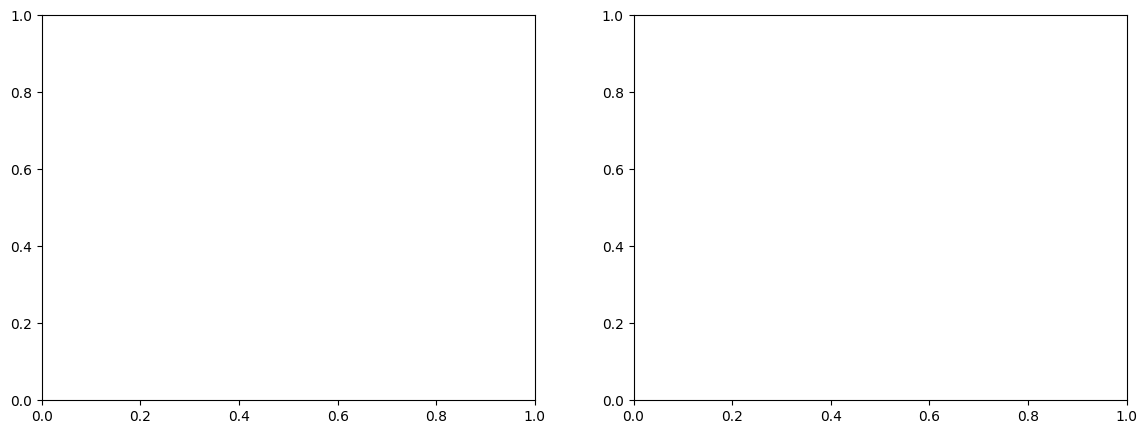

In [62]:
if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        print(f"\n❌ FATAL ERROR: {e}")
        import traceback
        traceback.print_exc()
        print("\n💡 Check the error above and try again")

In [ ]:
!pip install -q lxml_html_clean
!pip install -q wikipedia

import os
from io import BytesIO
from urllib.parse import urlparse, unquote

import requests
import wikipedia
from PIL import Image

wikipedia.set_lang("en")

print("Starting Wikipedia image scraping...")

# Correct Wikipedia page titles for each politician
WIKI_TITLES = {
    "imran_khan": "Imran Khan",
    "nawaz_sharif": "Nawaz Sharif",
    "asif_ali_zardari": "Asif Ali Zardari",
    "bilawal_bhutto": "Bilawal Bhutto Zardari",
    "shahbaz_sharif": "Shehbaz Sharif",
    "maryam_nawaz": "Maryam Nawaz",
    "fazlur_rehman": "Fazal-ur-Rehman (politician)",
    "asfandyar_wali": "Asfandyar Wali Khan",
    "altaf_hussain": "Altaf Hussain (Pakistani politician)",
    "chaudhry_shujaat": "Chaudhry Shujaat Hussain",
    "pervez_musharraf": "Pervez Musharraf",
    "shehryar_afridi": "Shehryar Afridi",
    "khawaja_asif": "Khawaja Asif",
    "ahsan_iqbal": "Ahsan Iqbal",
    "barrister_gohar": "Gohar Ali Khan",
    "ahmed_sharif_chaudhry": "Ahmed Sharif Chaudhry",
}

wiki_summary = {}
headers = {"User-Agent": "Mozilla/5.0"}

for name in POLITICIANS.keys():
    class_dir = os.path.join("data/raw", name)
    os.makedirs(class_dir, exist_ok=True)
    added = 0

    query_title = WIKI_TITLES.get(name, name.replace("_", " "))
    try:
        page = wikipedia.page(query_title)
    except wikipedia.exceptions.PageError:
        try:
            page = wikipedia.page(name.replace("_", " "))
        except wikipedia.exceptions.PageError:
            print(f"  ⚠️  Wikipedia page lookup failed for {name}")
            wiki_summary[name] = 0
            continue
    except Exception as e:
        print(f"  ⚠️  Wikipedia page lookup failed for {name}: {e}")
        wiki_summary[name] = 0
        continue

    for image_url in getattr(page, "images", []):
        filename = unquote(os.path.basename(urlparse(image_url).path))
        filename_lower = filename.lower()

        if not filename_lower.endswith((".jpg", ".jpeg", ".png")):
            continue
        if any(bad_word in filename_lower for bad_word in ["flag", "logo", "icon", "map", "symbol"]):
            continue

        save_path = os.path.join(class_dir, filename)
        if os.path.exists(save_path):
            continue

        try:
            response = requests.get(image_url, headers=headers, timeout=10)
            response.raise_for_status()
            with Image.open(BytesIO(response.content)) as img:
                img = img.convert("RGB")
                img.save(save_path)
            added += 1
        except Exception:
            continue

    wiki_summary[name] = added

print("\nWikipedia image scraping summary:")
for name in POLITICIANS.keys():
    print(f"  {name}: +{wiki_summary.get(name, 0)} new images")